In [80]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/sample_submission.csv
/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv
/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv


In [82]:
df['score'].value_counts()

score
0.0    1048333
1.0     303432
2.0     186279
3.0     118496
4.0      69422
5.0      31974
Name: count, dtype: int64

In [85]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# Define our feature columns (exclude targets, IDs, and raw dates)
features = [c for c in df.columns if c not in ['region_id', 'date', 'score', 
                                               'target_w1', 'target_w2', 'target_w3', 
                                               'target_w4', 'target_w5']]
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# 1. Get a sorted list of all unique dates in the dataset
unique_dates = sorted(df['date'].unique())

# 2. Find the index that represents the 80% cutoff point
split_index = int(len(unique_dates) * 0.8)

# 3. Get the actual date string at that position
split_date = unique_dates[split_index]
train = df[df['date'] < split_date]
val = df[df['date'] >= split_date]

X_train, y_train = train[features], train[targets]
X_val, y_val = val[features], val[targets]

# Set up LightGBM. Setting objective='mae' tells it to optimize for the Kaggle metric directly!
base_model = LGBMRegressor(objective='mae', n_estimators=100, random_state=42)

# Wrap it to predict all 5 weeks simultaneously
multi_model = MultiOutputRegressor(base_model)

# Train the model
multi_model.fit(X_train, y_train)

# Predict on validation set
preds = multi_model.predict(X_val)

# Post-processing: Clip predictions so they don't fall outside the 0-5 severity range
preds = np.clip(preds, 0, 5)

# Evaluate
mae = mean_absolute_error(y_val, preds)
print(f"Validation MAE: {mae:.4f}")

# Calculate and print the MAE for each week separately
for i, target_col in enumerate(targets):
    week_mae = mean_absolute_error(y_val[target_col], preds[:, i])
    print(f"Prediction for {target_col} MAE: {week_mae:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5402
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 24
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5402
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 24
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.131405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5402
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 24

In [86]:
# Quick code to see your top features for week 1
pd.DataFrame({
    'feature': X_train.columns,
    'importance': multi_model.estimators_[0].feature_importances_
}).sort_values('importance', ascending=False).head(10)

,feature,importance
18,prec_roll_mean_7,1189
17,score_lag_7,802
20,tmp_max_roll_mean_7,316
4,dp_tmp,204
23,humidity_roll_max_7,125
14,year,119
1,surf_pre,73
21,tmp_max_roll_max_7,57
22,humidity_roll_mean_7,56
5,wb_tmp,32


In [88]:
# Convert the region_id from a text string to a Pandas 'category' type
df['region_id'] = df['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = df.groupby('region_id')['score'].mean().reset_index()
region_avg_score.rename(columns={'score': 'region_historical_avg_score'}, inplace=True)

# Merge this back into your main dataframe
df = df.merge(region_avg_score, on='region_id', how='left')

# 1. Get a sorted list of all unique dates in the dataset
unique_dates = sorted(df['date'].unique())

# 2. Find the index that represents the 80% cutoff point
split_index = int(len(unique_dates) * 0.8)

# 3. Get the actual date string at that position
split_date = unique_dates[split_index]
train = df[df['date'] < split_date]
val = df[df['date'] >= split_date]

X_train, y_train = train[features], train[targets]
X_val, y_val = val[features], val[targets]

# Set up LightGBM. Setting objective='mae' tells it to optimize for the Kaggle metric directly!
base_model_2 = LGBMRegressor(objective='mae', n_estimators=100, random_state=42)

# Wrap it to predict all 5 weeks simultaneously
multi_model_2 = MultiOutputRegressor(base_model)

# Train the model
multi_model_2.fit(X_train, y_train)

# Predict on validation set
preds_2 = multi_model_2.predict(X_val)

# Post-processing: Clip predictions so they don't fall outside the 0-5 severity range
preds_2 = np.clip(preds_2, 0, 5)

# Evaluate
mae = mean_absolute_error(y_val, preds_2)
print(f"Validation MAE: {mae:.4f}")

# Calculate and print the MAE for each week separately
for i, target_col in enumerate(targets):
    week_mae = mean_absolute_error(y_val[target_col], preds_2[:, i])
    print(f"Prediction for {target_col} MAE: {week_mae:.4f}")

/tmp/ipykernel_57/71447921.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_avg_score = df.groupby('region_id')['score'].mean().reset_index()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.134149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11558
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 52
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11558
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 52
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.129127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11558
[LightGBM] [Info] Number of

In [89]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# 1. Define our customized feature sets for each week
# Notice how W1 uses 7/14 day features, while W5 relies heavily on 70/105 day features
feature_sets = {
    'target_w1': ['score_lag_7', 'prec_roll_mean_7', 'tmp_max_roll_max_7', 'region_historical_avg_score', 'month'],
    'target_w2': ['score_lag_7', 'prec_roll_mean_7', 'tmp_max_roll_max_7', 'score_lag_14', 'prec_roll_mean_14', 'tmp_max_roll_max_14', 'region_historical_avg_score', 'month'],
    'target_w3': ['score_lag_7', 'prec_roll_mean_7', 'tmp_max_roll_max_7', 'score_lag_21', 'prec_roll_mean_35', 'tmp_max_roll_max_35', 'region_historical_avg_score', 'month'],
    'target_w4': ['score_lag_7', 'prec_roll_mean_7', 'tmp_max_roll_max_7', 'score_lag_28', 'prec_roll_mean_70', 'tmp_max_roll_max_70', 'region_historical_avg_score', 'month'],
    'target_w5': ['score_lag_7', 'prec_roll_mean_7', 'tmp_max_roll_max_7', 'score_lag_35', 'prec_roll_mean_91', 'tmp_max_roll_max_91', 'region_historical_avg_score', 'month']
}
# (Add any other relevant features you engineered into these lists)
feature = [c for c in df.columns if c not in ['date', 'score', 'year', 'month', 'region_historical_avg_score', 'region_id',
                                               'score_lag_7','score_lag_14','score_lag_21','score_lag_28','score_lag_35',
                                               'prec_roll_mean_7','prec_roll_mean_14', 'prec_roll_mean_35','prec_roll_mean_70',
                                               'prec_roll_mean_91','tmp_max_roll_max_7','tmp_max_roll_max_14','tmp_max_roll_max_35',
                                               'tmp_max_roll_max_70','tmp_max_roll_max_91',
                                               'target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']]

targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# 3. Chronological Train/Validation Split
unique_dates = sorted(df['date'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train = df[df['date'] < split_date].copy()
val = df[df['date'] >= split_date].copy()

# 4. Train and Evaluate Loop
total_mae = 0
trained_models = {}

print("Training 5 separate specialized models...\n")

for target in targets:
    features = feature_sets[target] + feature
    
    # Isolate training and validation data for this specific target
    X_train_target = train[features]
    y_train_target = train[target]
    
    X_val_target = val[features]
    y_val_target = val[target]
    
    # Initialize heavily regularized LightGBM
    model = LGBMRegressor(
        objective='mae', 
        n_estimators=300, 
        learning_rate=0.05,
        colsample_bytree=0.7,   # Fights feature bloat
        min_child_samples=100,  # Prevents memorizing edge cases
        random_state=42,
        n_jobs=-1               # Use all CPU cores
    )
    
    # Train
    model.fit(X_train_target, y_train_target)
    trained_models[target] = model
    
    # Predict and Clip
    preds_3 = model.predict(X_val_target)
    preds_3 = np.clip(preds_3, 0, 5)
    
    # Evaluate
    mae = mean_absolute_error(y_val_target, preds_3)
    total_mae += mae
    print(f"Prediction for {target} MAE: {mae:.4f}")

# Final Score Calculation
final_competition_score = total_mae / 5
print(f"\nFinal Expected Leaderboard MAE: {final_competition_score:.4f}")

Training 5 separate specialized models...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.235105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9490
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 40
Prediction for target_w1 MAE: 0.1769
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.252029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10007
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 43
Prediction for target_w2 MAE: 0.2374
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.243651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10007
[LightGBM] [Info] Number of data points in the train set: 1391451, number of used features: 43
Predicti

In [91]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
import random

features = [c for c in df.columns if c not in ['date', 'score', 'year', 'region_historical_avg_score', 'region_id',
                                              'prec_roll_mean_35','prec_roll_mean_70',
                                              'prec_roll_mean_91','tmp_max_roll_max_35',
                                              'tmp_max_roll_max_70','tmp_max_roll_max_91',
                                              'target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']]

unique_dates = np.sort(df['date'].unique())
tscv = TimeSeriesSplit(n_splits=3)

fold = 1
mock_submission_scores = []

print("Starting Kaggle-Simulated Validation...\n")

for train_date_idx, val_date_idx in tscv.split(unique_dates):
    
    train_dates = unique_dates[train_date_idx]
    val_dates = unique_dates[val_date_idx]
    
    # We need to make sure our mock test dates have enough room 
    # at the end of the dataset so the target_w5 isn't NaN
    valid_test_dates = val_dates[:-35] 
    
    train = df[df['date'].isin(train_dates)].copy()
    val = df[df['date'].isin(val_dates)].copy()

    # INSIDE THE FOLD LOOP:
    train_avg = train.groupby('region_id')['score'].mean().reset_index(name='region_hist_avg')
    train = train.merge(train_avg, on='region_id', how='left')
    val = val.merge(train_avg, on='region_id', how='left')
    
    X_train, y_train = train[features], train[targets]
    
    # Train your winning simple model
    base_model = LGBMRegressor(objective='mae', n_estimators=100, random_state=42, n_jobs=-1)
    multi_model = MultiOutputRegressor(base_model)
    multi_model.fit(X_train, y_train)
    
    # --- THE CADENCE FIX: SIMULATE KAGGLE SUBMISSIONS ---
    # Pick 3 random days in this fold to act as our "Kaggle Test Set cutoffs"
    random.seed(42)
    mock_dates = random.sample(list(valid_test_dates), 3)
    
    fold_mae_list = []
    
    for mock_date in mock_dates:
        # Isolate ONLY the single day for all regions (just like the test.csv)
        mock_test_set = val[val['date'] == mock_date]
        
        X_mock = mock_test_set[features]
        y_mock_true = mock_test_set[targets]
        
        # Predict
        preds = multi_model.predict(X_mock)
        preds = np.clip(preds, 0, 5)
        
        # Calculate MAE for this single day across all regions
        mae = mean_absolute_error(y_mock_true, preds)
        fold_mae_list.append(mae)
    
    # Average the score of our 3 mock submissions for this fold
    fold_avg_mae = np.mean(fold_mae_list)
    mock_submission_scores.append(fold_avg_mae)
    
    print(f"Fold {fold} | Mock Kaggle MAE: {fold_avg_mae:.4f}")
    fold += 1

print(f"\nTrue Simulated Leaderboard MAE: {np.mean(mock_submission_scores):.4f}")

Starting Kaggle-Simulated Validation...



/tmp/ipykernel_57/3470313384.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_avg = train.groupby('region_id')['score'].mean().reset_index(name='region_hist_avg')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9709
[LightGBM] [Info] Number of data points in the train set: 453644, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.081897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9709
[LightGBM] [Info] Number of data points in the train set: 453644, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9709
[LightGBM] [Info] Number of data points in the train set: 453644, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.083400 seconds.
You can set `force_col_wis

/tmp/ipykernel_57/3470313384.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_avg = train.groupby('region_id')['score'].mean().reset_index(name='region_hist_avg')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 868124, number of used features: 42
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 868124, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.166204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 868124, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the over

/tmp/ipykernel_57/3470313384.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_avg = train.groupby('region_id')['score'].mean().reset_index(name='region_hist_avg')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.105467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 1300147, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 1300147, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.245277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9752
[LightGBM] [Info] Number of data points in the train set: 1300147, number of used features: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the o

In [103]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import random

# Ensure your raw data is purely chronological by region
df = df.sort_values(['region_id', 'date']).reset_index(drop=True)
unique_dates = np.sort(df['date'].unique())

# Create the future targets by shifting the score column backward
print("Generating future targets...")
df['target_w1'] = df.groupby('region_id')['score'].shift(-7)
df['target_w2'] = df.groupby('region_id')['score'].shift(-14)
df['target_w3'] = df.groupby('region_id')['score'].shift(-21)
df['target_w4'] = df.groupby('region_id')['score'].shift(-28)
df['target_w5'] = df.groupby('region_id')['score'].shift(-35)

# (Do not use df.dropna() here, let the NaN values stay at the very end of the dataset!)

# Setup feature helper to build windows strictly on a slice of data
def build_features_for_window(window_df):
    """
    Expects a DataFrame containing exactly 91 days of history.
    Computes features on the very last day (Day 91) to predict the future.
    """
    # 7-day and 14-day weather statistics
    window_df['prec_roll_mean_7'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(7).mean())
    window_df['tmp_max_roll_max_7'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(7).max())
    window_df['prec_roll_mean_14'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(14).mean())
    window_df['tmp_max_roll_max_14'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(14).max())
    window_df['prec_roll_mean_35'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(35).mean())
    window_df['tmp_max_roll_max_35'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(35).max())
    window_df['prec_roll_mean_70'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(70).mean())
    window_df['prec_roll_mean_70'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(70).mean())
    window_df['tmp_max_roll_max_91'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(91).max())
    window_df['prec_roll_mean_91'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(91).mean())
    
    # Lags for the disaster score
    window_df['score_lag_7'] = window_df.groupby('region_id')['score'].shift(7)
    window_df['score_lag_14'] = window_df.groupby('region_id')['score'].shift(14)
    window_df['score_lag_21'] = window_df.groupby('region_id')['score'].shift(21)
    window_df['score_lag_28'] = window_df.groupby('region_id')['score'].shift(28)
    window_df['score_lag_35'] = window_df.groupby('region_id')['score'].shift(35)
    
    # Extract only the 91st day (the final day of history) for each region
    final_day_features = window_df.groupby('region_id').last().reset_index()
    return final_day_features

# --- SIMULATED 91-DAY TEST SPLIT LOOP ---
# Let's run 5 random test windows across your validation timeframe
random.seed(42)
validation_start_idx = int(len(unique_dates) * 0.8)
val_dates_pool = unique_dates[validation_start_idx : -35] # Leave 35 days at the end for targets

window_maes = []

print("Running Strict 91-Day Window Simulation...\n")

for i in range(10):
    # 1. Pick a random date to be "Day 91" (the cutoff date)
    cutoff_date = random.choice(val_dates_pool)
    cutoff_idx = np.where(unique_dates == cutoff_date)[0][0]
    
    # 2. Extract exactly 91 days of history leading up to this date
    history_dates = unique_dates[cutoff_idx - 90 : cutoff_idx + 1]
    raw_history_chunk = df[df['date'].isin(history_dates)].copy()
    
    # ... (Steps 1, 2, 3 remain exactly the same) ...
    # 3. Build features on this isolated history chunk (No data leakage!)
    X_val_mock = build_features_for_window(raw_history_chunk)
    
    # 4. Extract Targets
    target_cols = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
    y_val_mock_true = df[df['date'] == cutoff_date][['region_id'] + target_cols]
    
    # --- THE FIX ---
    # Drop the targets from X so Pandas doesn't rename them to _x and _y during the merge
    X_val_mock = X_val_mock.drop(columns=target_cols, errors='ignore')
    
    # Merge X and y together on region_id
    aligned_data = pd.merge(X_val_mock, y_val_mock_true, on='region_id', how='inner')
    
    # Extract the perfectly aligned features and true targets
    y_aligned_true = aligned_data[target_cols]
    
    # 5. Predict using your pre-trained model
    # (Define your feature list as you did before)
    features = [c for c in aligned_data.columns if c not in ['date', 'score', 'year', 'region_historical_avg_score', 'region_id',
                                                             'target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']]
    
    features = [c for c in features if c in aligned_data.columns]
    
    preds = multi_model_1.predict(aligned_data[features])
    preds = np.clip(preds, 0, 5)
    
    # 6. Calculate MAE
    mae = mean_absolute_error(y_aligned_true, preds)
    window_maes.append(mae)
    
    print(f"Simulation {i+1} | Cutoff Date: {cutoff_date} | Evaluated Regions: {len(aligned_data)} | MAE: {mae:.4f}")

print(f"\nFinal Window-Simulated MAE: {np.mean(window_maes):.4f}")

Generating future targets...
Running Strict 91-Day Window Simulation...



/tmp/ipykernel_57/4254021957.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['target_w1'] = df.groupby('region_id')['score'].shift(-7)
/tmp/ipykernel_57/4254021957.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['target_w2'] = df.groupby('region_id')['score'].shift(-14)
/tmp/ipykernel_57/4254021957.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['target_w3'] = df.groupby('region_id')['score'].shif

Simulation 1 | Cutoff Date: 50445-08-31 | Evaluated Regions: 2 | MAE: 1.7000


/tmp/ipykernel_57/4254021957.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['prec_roll_mean_7'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(7).mean())
/tmp/ipykernel_57/4254021957.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['tmp_max_roll_max_7'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(7).max())
/tmp/ipykernel_57/4254021957.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

Simulation 2 | Cutoff Date: 50270-04-23 | Evaluated Regions: 1 | MAE: 0.7455


...

Simulation 8 | Cutoff Date: 50394-05-24 | Evaluated Regions: 2 | MAE: 0.5163


/tmp/ipykernel_57/4254021957.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['prec_roll_mean_7'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(7).mean())
/tmp/ipykernel_57/4254021957.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['tmp_max_roll_max_7'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(7).max())
/tmp/ipykernel_57/4254021957.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

Simulation 9 | Cutoff Date: 6031-11-27 | Evaluated Regions: 1 | MAE: 0.4164


/tmp/ipykernel_57/4254021957.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['prec_roll_mean_7'] = window_df.groupby('region_id')['prec'].transform(lambda x: x.rolling(7).mean())
/tmp/ipykernel_57/4254021957.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_df['tmp_max_roll_max_7'] = window_df.groupby('region_id')['tmp_max'].transform(lambda x: x.rolling(7).max())
/tmp/ipykernel_57/4254021957.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

Simulation 10 | Cutoff Date: 50283-09-21 | Evaluated Regions: 2 | MAE: 0.6000

Final Window-Simulated MAE: 0.7186


In [107]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Start with your fully prepared 'df' (after you generated all rolling features and targets)
# We need to filter out rows that can't be used for testing
# Drop the very end where targets are NaN, and the very beginning where rolling windows are NaN
valid_df = df.dropna(subset=['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5', 'prec_roll_mean_7']).copy()

# 2. Sample 5 random days for EVERY region
# If a region has less than 5 days total, we just take whatever it has
mock_test_set = valid_df.groupby('region_id').sample(n=5, replace=True, random_state=42).reset_index(drop=True)

print(f"Created a robust Mock Test Set with {len(mock_test_set)} rows!")
print(f"Total Unique Regions Evaluated: {mock_test_set['region_id'].nunique()}")

# 3. Define the exact features your model expects
# (Ensure this matches exactly what you used to train multi_model)
features = [c for c in valid_df.columns if c not in ['date', 'score', 'year', 'region_historical_avg_score', 'region_id',
                                                     'score_lag_21', 'score_lag_28', 'score_lag_35',
                                                     'prec_roll_mean_35','prec_roll_mean_70',
                                                     'prec_roll_mean_91','tmp_max_roll_max_35',
                                                     'tmp_max_roll_max_70','tmp_max_roll_max_91',
                                                     'target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']]

# 4. Predict
X_test_mock = mock_test_set[features]
y_test_mock_true = mock_test_set[['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']]

preds = multi_model.predict(X_test_mock)
preds = np.clip(preds, 0, 5)

# 5. Calculate Final MAE
mae = mean_absolute_error(y_test_mock_true, preds)

print(f"\nFinal Robust Region-Centric MAE: {mae:.4f}")

/tmp/ipykernel_57/4060848837.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mock_test_set = valid_df.groupby('region_id').sample(n=5, replace=True, random_state=42).reset_index(drop=True)


Created a robust Mock Test Set with 11240 rows!
Total Unique Regions Evaluated: 2248

Final Robust Region-Centric MAE: 0.6923


In [1]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Assuming the date format is "3006-01-25"
df['year'] = df['date'].str[0:4].astype(int)
df['month'] = df['date'].str[5:7].astype(int)
df['day'] = df['date'].str[8:10].astype(int)
print("Loading and sorting data...")
# Assuming your main training dataframe is called 'df'
df = df.sort_values(['region_id', 'date']).reset_index(drop=True).copy()

# ==========================================
# 1. GENERATE TARGETS (Future Scores)
# ==========================================
print("Generating targets...")
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    df[t] = df.groupby('region_id')['score'].shift(-(i+1)*7)

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
print("Engineering features...")
# Focus strictly on the heaviest hitters
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre']

# Rolling Windows (7, 14, 35, 70, 91)
windows = [7, 14, 35, 70, 91]
for w in windows:
    for col in weather_cols:
        df[f'{col}_roll_mean_{w}'] = df.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        df[f'{col}_roll_max_{w}'] = df.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Score Lags (14, 21, 28, 35)
lags = [14, 21, 28, 35]
for l in lags:
    df[f'score_lag_{l}'] = df.groupby('region_id')['score'].shift(l)

features = [c for c in df.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

# ==========================================
# 3. THE 7-DAY FILTER & CHRONOLOGICAL SPLIT
# ==========================================
print("Filtering for valid scoring days and splitting data...")
# Drop the 6 "empty" days to strictly train on valid target cadences
modeling_df = df.dropna(subset=targets + ['score']).copy()

unique_dates = sorted(modeling_df['date'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train = modeling_df[modeling_df['date'] < split_date].copy()
val = modeling_df[modeling_df['date'] >= split_date].copy()

X_train, y_train = train[features], train[targets]

# ==========================================
# 4. TRAIN THE MODEL
# ==========================================
print(f"Training multi-output model on {len(X_train)} rows...")
base_model = LGBMRegressor(
    objective='mae', 
    n_estimators=150, 
    learning_rate=0.05, 
    random_state=42, 
    n_jobs=-1
)
multi_model = MultiOutputRegressor(base_model)
multi_model.fit(X_train, y_train)

# ==========================================
# 5. REGION-CENTRIC VALIDATION
# ==========================================
print("Running region-centric evaluation...")
# Sample 5 random valid scoring days for each region strictly from the validation set
mock_test_set = val.groupby('region_id').sample(n=15, replace=True, random_state=42).reset_index(drop=True)

X_val_mock = mock_test_set[features]
y_val_mock_true = mock_test_set[targets]

preds = multi_model.predict(X_val_mock)
preds = np.clip(preds, 0, 5)

final_mae = mean_absolute_error(y_val_mock_true, preds)

print("-" * 30)
print(f"Total rows in leak-free mock test: {len(mock_test_set)}")
print(f"Final True Region-Centric MAE: {final_mae:.4f}")
print("-" * 30)

# Print week-by-week breakdown
for i, target_col in enumerate(targets):
    week_mae = mean_absolute_error(y_val_mock_true[target_col], preds[:, i])
    print(f"Prediction for {target_col} MAE: {week_mae:.4f}")

Loading and sorting data...
Generating targets...
Engineering features...
Filtering for valid scoring days and splitting data...
Training multi-output model on 1393242 rows...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.576919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16397
[LightGBM] [Info] Number of data points in the train set: 1393242, number of used features: 70
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.578219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16397
[LightGBM] [Info] Number of data points in the train set: 1393242, number of used features: 70
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.583642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16397
[LightGBM] [Info] Number of data points in 

In [5]:
mock_test_set = val.groupby('region_id').sample(n=5, replace=True, random_state=42).reset_index(drop=True)

X_val_mock = mock_test_set[features]
y_val_mock_true = mock_test_set[targets]

preds = multi_model.predict(X_val_mock)
preds = np.clip(preds, 0, 5)

final_mae = mean_absolute_error(y_val_mock_true, preds)

print("-" * 30)
print(f"Total rows in leak-free mock test: {len(mock_test_set)}")
print(f"Final True Region-Centric MAE: {final_mae:.4f}")
print("-" * 30)

# Print week-by-week breakdown
for i, target_col in enumerate(targets):
    week_mae = mean_absolute_error(y_val_mock_true[target_col], preds[:, i])
    print(f"Prediction for {target_col} MAE: {week_mae:.4f}")

------------------------------
Total rows in leak-free mock test: 2295
Final True Region-Centric MAE: 0.3216
------------------------------
Prediction for target_w1 MAE: 0.2251
Prediction for target_w2 MAE: 0.2791
Prediction for target_w3 MAE: 0.3301
Prediction for target_w4 MAE: 0.3715
Prediction for target_w5 MAE: 0.4023


In [9]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# --- FIX BUG 1: ROBUST DATE PARSING (Handles 4-digit and 5-digit years perfectly) ---
print("Parsing dates safely...")
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

# Sort chronologically to preserve sequence integrity
train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# ==========================================
# 2. GENERATE TARGETS ON FULL TRAIN DATA
# ==========================================
print("2. Engineering targets on Train Data...")
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# ==========================================
# 3. PURE WEATHER FEATURE ENGINEERING
# ==========================================
print("3. Engineering weather rolling windows...")
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre']
windows = [7, 14, 35, 70, 91]

# Compute rolling windows for Training Set
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Compute rolling windows for Test Set (Completely self-contained within its 91 days!)
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Define features (No score_lags allowed!)
features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

# Filter down to valid weekly scoring cadences across the entire training set
train_final = train_raw.dropna(subset=targets + ['score']).copy()

X_train = train_final[features]
y_train = train_final[targets]

# ==========================================
# 4. TRAIN THE FINAL MODEL
# ==========================================
print(f"4. Retraining model on ALL {len(X_train)} rows using pure weather signals...")
base_model = LGBMRegressor(
    objective='mae', 
    n_estimators=150, 
    learning_rate=0.05, 
    random_state=42, 
    n_jobs=-1
)
final_multi_model = MultiOutputRegressor(base_model)
final_multi_model.fit(X_train, y_train)

# ==========================================
# 5. EXTRACT TEST INDICES & PREDICT
# ==========================================
print("5. Generating dynamic predictions...")
# Group by region and select the 91st day (the last row) to capture the completed rolling stats
test_final_rows = test_raw.groupby('region_id').last().reset_index()

X_test = test_final_rows[features]

test_preds = final_multi_model.predict(X_test)
test_preds = np.clip(test_preds, 0, 5)

# ==========================================
# 6. EXPORT CLEAN SUBMISSION
# ==========================================
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': test_preds[:, 0],
    'pred_week2': test_preds[:, 1],
    'pred_week3': test_preds[:, 2],
    'pred_week4': test_preds[:, 3],
    'pred_week5': test_preds[:, 4]
})

submission.to_csv('submission.csv', index=False)
print("\nSuccess! A valid, dynamically varied 'submission.csv' has been generated.")

1. Loading raw datasets...
Parsing dates safely...
2. Engineering targets on Train Data...
3. Engineering weather rolling windows...
4. Retraining model on ALL 1746696 rows using pure weather signals...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.694053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16365
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 66
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.705789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16365
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 66
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.697855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16365
[LightGBM] [Info

In [8]:
print("Last training date in train.csv:", train_raw['date'].max())
print("First testing date in test.csv:", test_raw['date'].min())
print("Number of unique regions in test.csv:", test_raw['region_id'].nunique())
print("Total rows in test.csv:", test_raw.shape[0])

Last training date in train.csv: 8133-12-31
First testing date in test.csv: 10021-08-12
Number of unique regions in test.csv: 2248
Total rows in test.csv: 204568


In [1]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import RegressorChain

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# --- ROBUST DATE PARSING (Handles 4-digit and 5-digit years cleanly) ---
print("Parsing dates dynamically...")
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

# Sort chronologically to preserve sequence integrity
train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# ==========================================
# 2. STRATEGY 2: CLIMATE ANOMALY BASELINE MAP
# ==========================================
print("2. Computing regional climate baselines...")
# Calculate historical average rain and max temperature for each region per month
climate_normals = train_raw.groupby(['region_id', 'month'])[['prec', 'tmp_max']].mean().reset_index()
climate_normals = climate_normals.rename(columns={'prec': 'normal_prec', 'tmp_max': 'normal_tmp_max'})

# Calculate global monthly fallbacks in case the test set hits a rare new region/month combination
global_monthly_prec = train_raw.groupby('month')['prec'].mean().to_dict()
global_monthly_tmp = train_raw.groupby('month')['tmp_max'].mean().to_dict()

# Merge the baseline context profiles into both matrices
train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Robust fallback mapping for missing values
train_raw['normal_prec'] = train_raw['normal_prec'].fillna(train_raw['month'].map(global_monthly_prec))
train_raw['normal_tmp_max'] = train_raw['normal_tmp_max'].fillna(train_raw['month'].map(global_monthly_tmp))
test_raw['normal_prec'] = test_raw['normal_prec'].fillna(test_raw['month'].map(global_monthly_prec))
test_raw['normal_tmp_max'] = test_raw['normal_tmp_max'].fillna(test_raw['month'].map(global_monthly_tmp))

# ==========================================
# 3. GENERATE TARGETS ON FULL TRAIN DATA
# ==========================================
print("3. Shifting historical training targets...")
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# ==========================================
# 4. WEATHER FEATURE ENGINEERING
# ==========================================
print("4. Rolling out weather windows & computing deviations...")
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre']
windows = [7, 14, 35, 70, 91]

# Feature expansion loop for Training Data
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Feature expansion loop for Test Data (Self-contained)
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# --- CALCULATE ANOMALIES (Current state minus regional expectation) ---
for w in windows:
    train_raw[f'prec_anomaly_{w}'] = train_raw[f'prec_roll_mean_{w}'] - train_raw['normal_prec']
    train_raw[f'tmp_max_anomaly_{w}'] = train_raw[f'tmp_max_roll_max_{w}'] - train_raw['normal_tmp_max']
    
    test_raw[f'prec_anomaly_{w}'] = test_raw[f'prec_roll_mean_{w}'] - test_raw['normal_prec']
    test_raw[f'tmp_max_anomaly_{w}'] = test_raw[f'tmp_max_roll_max_{w}'] - test_raw['normal_tmp_max']

# Define exact usable feature strings (Dropping IDs, raw scores, years, and labels)
features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

# --- THE FIX ---
# Drop empty cadences AND rows at the very start where the 91-day window isn't fully ready
train_final = train_raw.dropna(subset=targets + ['score', 'prec_roll_mean_91']).copy()

# Add .fillna(0) to satisfy Scikit-Learn's strict non-NaN entry requirement
X_train = train_final[features].fillna(0)
y_train = train_final[targets]

# ==========================================
# 5. STRATEGY 3: HIGH-CAPACITY TUNED MODEL
# ==========================================
print(f"5. Tuning and preparing base LightGBM structures...")
tuned_lgbm = LGBMRegressor(
    objective='mae', 
    n_estimators=1000,       # Deep learning horizon
    learning_rate=0.015,     # Conservative stepping to isolate patterns
    num_leaves=63,           # Highly flexible branching depth
    subsample=0.8,           # row sampling to insulate against tabular noise
    colsample_bytree=0.8,    # feature sampling to insulate against redundant indicators
    random_state=42, 
    n_jobs=-1
)

# ==========================================
# 6. STRATEGY 1: CONSTRUCT REGRESSOR CHAIN
# ==========================================
print(f"6. Linking models into a Regressor Chain and training on {len(X_train)} rows...")
# Replaces MultiOutputRegressor. Chronologically links future predictions together!
final_chain_model = RegressorChain(tuned_lgbm)
final_chain_model.fit(X_train, y_train)

# ==========================================
# 7. INFERENCE AND PRODUCTION FILE GENERATION
# ==========================================
print("7. Extracting terminal feature states and predicting...")
# Compress the test dataframe down to exactly Day 91 (the absolute last day) per region
test_final_rows = test_raw.groupby('region_id').last().reset_index()

# --- THE FIX ---
# Add .fillna(0) here as well to protect the chain model's .predict() validation step
X_test = test_final_rows[features].fillna(0)

# Chain model automatically feeds week 1 prediction into the week 2 features under the hood
test_preds = final_chain_model.predict(X_test)
test_preds = np.clip(test_preds, 0, 5)

print("8. Structuring final submission layout...")
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': test_preds[:, 0],
    'pred_week2': test_preds[:, 1],
    'pred_week3': test_preds[:, 2],
    'pred_week4': test_preds[:, 3],
    'pred_week5': test_preds[:, 4]
})

submission.to_csv('submission.csv', index=False)
print("\nExecution complete! Upload 'submission.csv' directly to the Kaggle dashboard.")

1. Loading raw datasets...
Parsing dates dynamically...
2. Computing regional climate baselines...
3. Shifting historical training targets...
4. Rolling out weather windows & computing deviations...
5. Tuning and preparing base LightGBM structures...
6. Linking models into a Regressor Chain and training on 1719720 rows...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.844136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19425
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.806484 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19431
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 79
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.8359

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

8. Structuring final submission layout...

Execution complete! Upload 'submission.csv' directly to the Kaggle dashboard.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [3]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
# Define features (No score_lags allowed!)
features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

# Filter down to valid weekly scoring cadences across the entire training set
train_final = train_raw.dropna(subset=targets + ['score']).copy()

X_train = train_final[features]
y_train = train_final[targets]

# ==========================================
# 4. TRAIN THE FINAL MODEL
# ==========================================
print(f"4. Retraining model on ALL {len(X_train)} rows using pure weather signals...")
base_model = LGBMRegressor(
    objective='mae', 
    n_estimators=250, 
    learning_rate=0.05, 
    random_state=42, 
    n_jobs=-1
)
final_multi_model = MultiOutputRegressor(base_model)
final_multi_model.fit(X_train, y_train)

# ==========================================
# 5. EXTRACT TEST INDICES & PREDICT
# ==========================================
print("5. Generating dynamic predictions...")
# Group by region and select the 91st day (the last row) to capture the completed rolling stats
test_final_rows = test_raw.groupby('region_id').last().reset_index()

X_test = test_final_rows[features]

test_preds = final_multi_model.predict(X_test)
test_preds = np.clip(test_preds, 0, 5)

# ==========================================
# 6. EXPORT CLEAN SUBMISSION
# ==========================================
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': test_preds[:, 0],
    'pred_week2': test_preds[:, 1],
    'pred_week3': test_preds[:, 2],
    'pred_week4': test_preds[:, 3],
    'pred_week5': test_preds[:, 4]
})

submission.to_csv('submission.csv', index=False)
print("\nSuccess! A valid, dynamically varied 'submission.csv' has been generated.")

4. Retraining model on ALL 1746696 rows using pure weather signals...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.953417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19425
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.917115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19425
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.908196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19425
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threadi

In [1]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates safely
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Add Atmospheric Thirst Feature
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Baselines
cols_to_baseline = ['prec', 'tmp_max', 'humidity', 'surf_pre', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Generate targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# Rolling Windows
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
windows = [7, 14, 35, 70, 91]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
for w in [14, 35, 91]:
    for col in ['prec', 'tmp_max', 'humidity', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]
train_final = train_raw.dropna(subset=targets + ['score', 'prec_roll_mean_91']).copy()

X_train = train_final[features].fillna(0)
y_train = train_final[targets]

# High capacity base model
tuned_lgbm = LGBMRegressor(
    objective='mae', 
    n_estimators=400,        # Increased from 250 for deeper capacity
    learning_rate=0.03,      # Slower learning rate for stable convergence
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, 
    n_jobs=-1
)

# Parallel multi-output architecture
final_multi_model = MultiOutputRegressor(tuned_lgbm)
print(f"Training parallel model on {len(X_train)} rows...")
final_multi_model.fit(X_train, y_train)

# Predict
test_final_rows = test_raw.groupby('region_id').last().reset_index()
X_test = test_final_rows[features].fillna(0)

test_preds = final_multi_model.predict(X_test)
test_preds = np.clip(test_preds, 0, 5)

# Format Submission
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': test_preds[:, 0],
    'pred_week2': test_preds[:, 1],
    'pred_week3': test_preds[:, 2],
    'pred_week4': test_preds[:, 3],
    'pred_week5': test_preds[:, 4]
})

submission.to_csv('submission.csv', index=False)
print("\nSuccess! A parallel-tuned submission file with active timeline variation is ready.")

1. Loading raw datasets...
Training parallel model on 1719720 rows...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.083736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.275490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.231713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threadi

In [2]:
# Positive = getting wetter than the long-term trend; Negative = flash-drying
train_raw['prec_velocity'] = train_raw['prec_roll_mean_7'] - train_raw['prec_roll_mean_35']
train_raw['tmp_velocity'] = train_raw['tmp_max_roll_mean_7'] - train_raw['tmp_max_roll_mean_35']

test_raw['prec_velocity'] = test_raw['prec_roll_mean_7'] - test_raw['prec_roll_mean_35']
test_raw['tmp_velocity'] = test_raw['tmp_max_roll_mean_7'] - test_raw['tmp_max_roll_mean_35']

In [3]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
import pandas as pd
import numpy as np

# ==========================================
# 1. DEFINE THE THREE HIGH-CAPACITY MODELS
# ==========================================
print("Initializing the Tabular Holy Trinity...")

# LightGBM (Current Baseline)
lgbm_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=450, learning_rate=0.03,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
))

# XGBoost (Depth-wise growth, robust splitting)
xgb_model = MultiOutputRegressor(XGBRegressor(
    objective='reg:absoluteerror', n_estimators=400, learning_rate=0.03,
    max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
))

# CatBoost (Symmetric trees, built-in interaction mastery)
cat_model = MultiOutputRegressor(CatBoostRegressor(
    loss_function='MAE', iterations=500, learning_rate=0.04,
    depth=6, random_seed=42, verbose=0, thread_count=-1
))

# ==========================================
# 2. TRAIN ALL THREE MODELS ON 100% OF DATA
# ==========================================
# (Assuming X_train and y_train contain your updated velocity + 180-day anomaly features)
print("Training LightGBM...")
lgbm_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Training CatBoost...")
cat_model.fit(X_train, y_train)

# ==========================================
# 3. BLEND INFERENCE VIA WEIGHTED AVERAGE
# ==========================================
print("Generating predictions from all models...")
preds_lgbm = np.clip(lgbm_model.predict(X_test), 0, 5)
preds_xgb  = np.clip(xgb_model.predict(X_test), 0, 5)
preds_cat  = np.clip(cat_model.predict(X_test), 0, 5)

# Assign weights based on individual performance (giving LightGBM the highest share)
final_preds = (preds_lgbm * 0.50) + (preds_xgb * 0.25) + (preds_cat * 0.25)

# ==========================================
# 4. EXPORT FINAL SUBMISSION
# ==========================================
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': final_preds[:, 0],
    'pred_week2': final_preds[:, 1],
    'pred_week3': final_preds[:, 2],
    'pred_week4': final_preds[:, 3],
    'pred_week5': final_preds[:, 4]
})
submission.to_csv('submission.csv', index=False)
print("\nMulti-model blend complete! Submission file generated successfully.")

Initializing the Tabular Holy Trinity...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.189970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.374690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.178319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 94
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the 

In [1]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

# Set device confirmation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp_max', 'humidity', 'surf_pre', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
windows = [7, 14, 35, 70, 91]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [14, 35, 91]:
    for col in ['prec', 'tmp_max', 'humidity', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]
train_final = train_raw.dropna(subset=targets + ['score', 'prec_roll_mean_91']).copy()

# ==========================================
# STAGE 1: THE LABORATORY (Find Optimal Weights)
# ==========================================
print("\n--- STAGE 1: FINDING OPTIMAL WEIGHTS ---")
unique_dates = sorted(train_final['date'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)] 

train_split = train_final[train_final['date'] < split_date]
val_split = train_final[train_final['date'] >= split_date]

X_train_val = train_split[features].fillna(0)
y_train_val = train_split[targets]
X_val = val_split[features].fillna(0)
y_val = val_split[targets]

print("Training Laboratory Models on 80% split with GPU...")
lgbm_eval = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=900, learning_rate=0.015, num_leaves=95, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X_train_val, y_train_val)

xgb_eval = MultiOutputRegressor(XGBRegressor(
    objective='reg:absoluteerror', n_estimators=800, learning_rate=0.015, max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist', device='cuda'
)).fit(X_train_val, y_train_val)

preds_val_lgbm = np.clip(lgbm_eval.predict(X_val), 0, 5)
preds_val_xgb  = np.clip(xgb_eval.predict(X_val), 0, 5)

print("Running Grid Search for optimal blend...")
best_mae = float('inf')
best_weights = (0, 0)

for w_lgbm in np.linspace(0, 1, 101):
    w_xgb = 1.0 - w_lgbm  # Forces them to equal exactly 100% together
    
    blend_val = (preds_val_lgbm * w_lgbm) + (preds_val_xgb * w_xgb)
    current_mae = mean_absolute_error(y_val, blend_val)
    
    if current_mae < best_mae:
        best_mae = current_mae
        best_weights = (w_lgbm, w_xgb)

print(f"Optimal Weights Found -> LightGBM: {best_weights[0]:.2f} | XGBoost: {best_weights[1]:.2f}")

# Free up memory before final training
del lgbm_eval, xgb_eval, X_train_val, y_train_val, X_val, y_val
gc.collect()

# ==========================================
# STAGE 2: PRODUCTION (Train on 100% Data)
# ==========================================
print("\n--- STAGE 2: FULL DATASET PRODUCTION ---")
X_train_full = train_final[features].fillna(0)
y_train_full = train_final[targets]

print(f"Training Final Deep Models on 100% of data ({len(X_train_full)} rows) with GPU...")
lgbm_final = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=900, learning_rate=0.015, num_leaves=95, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X_train_full, y_train_full)

xgb_final = MultiOutputRegressor(XGBRegressor(
    objective='reg:absoluteerror', n_estimators=800, learning_rate=0.015, max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist', device='cuda'
)).fit(X_train_full, y_train_full)

# ==========================================
# INFERENCE & SUBMISSION
# ==========================================
print("\nPredicting final Test Set applying Optimal Weights...")
test_final_rows = test_raw.groupby('region_id').last().reset_index()
X_test = test_final_rows[features].fillna(0)

preds_test_lgbm = np.clip(lgbm_final.predict(X_test), 0, 5)
preds_test_xgb  = np.clip(xgb_final.predict(X_test), 0, 5)

final_test_preds = (preds_test_lgbm * best_weights[0]) + (preds_test_xgb * best_weights[1])
final_test_preds = np.clip(final_test_preds, 0, 5)

submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': final_test_preds[:, 0],
    'pred_week2': final_test_preds[:, 1],
    'pred_week3': final_test_preds[:, 2],
    'pred_week4': final_test_preds[:, 3],
    'pred_week5': final_test_preds[:, 4]
})

submission.to_csv('submission_deep_duo_gpu.csv', index=False)
print("\nPipeline complete! 100% Data trained and perfectly weighted.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

--- STAGE 1: FINDING OPTIMAL WEIGHTS ---
Training Laboratory Models on 80% split with GPU...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1371786, number of used features: 94
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 94 dense feature groups (125.59 MB) transferred to GPU in 0.094326 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1371786, number of used features: 94
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 94 dense feature groups (125.59 MB) transferred to GPU in 0.095166 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 23505
[LightGBM] [Info] Number of data points in the train set: 1371786, number of used features: 94
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compili

In [1]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
import gc

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates dynamically (handles 4 and 5 digit years flawlessly)
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Feature 1: Atmospheric Thirst (Evaporative Stress)
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines Mapping
cols_to_baseline = ['prec', 'tmp_max', 'humidity', 'surf_pre', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Future shift targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# Broad rolling windows
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
windows = [7, 14, 35, 70, 91]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())
        test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# --- ADVANCED UPGRADE: TREND VELOCITIES ---
print("Computing meteorological velocity vectors...")
train_raw['prec_velocity'] = train_raw['prec_roll_mean_14'] - train_raw['prec_roll_mean_91']
train_raw['tmp_velocity'] = train_raw['tmp_max_roll_mean_14'] - train_raw['tmp_max_roll_mean_91']
test_raw['prec_velocity'] = test_raw['prec_roll_mean_14'] - test_raw['prec_roll_mean_91']
test_raw['tmp_velocity'] = test_raw['tmp_max_roll_mean_14'] - test_raw['tmp_max_roll_mean_91']

# Regional Deviations (Anomalies)
for w in [7, 14, 35, 91]:
    for col in ['prec', 'tmp_max', 'humidity', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Clean extraction matrices
features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]
train_final = train_raw.dropna(subset=targets + ['score', 'prec_roll_mean_91']).copy()

X_train = train_final[features].fillna(0)
y_train = train_final[targets]

# Memory Cleanup prior to model instantiation
del train_raw, train_final
gc.collect()

# ==========================================
# TRAINING THE ADVANCED VELOCITY ENSEMBLE
# ==========================================
print(f"\nTraining parallel ensemble models on {len(X_train)} rows...")

# 1. LightGBM (Weighted at 50%)
print("Fitting LightGBM Regressor...")
lgbm_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=450, learning_rate=0.03,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
))
lgbm_model.fit(X_train, y_train)

# 2. XGBoost (Weighted at 25%)
print("Fitting XGBoost Regressor...")
xgb_model = MultiOutputRegressor(XGBRegressor(
    objective='reg:absoluteerror', n_estimators=400, learning_rate=0.03,
    max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
))
xgb_model.fit(X_train, y_train)

# 3. CatBoost (Weighted at 25%)
print("Fitting CatBoost Regressor...")
cat_model = MultiOutputRegressor(CatBoostRegressor(
    loss_function='MAE', iterations=500, learning_rate=0.04,
    depth=6, random_seed=42, verbose=0, thread_count=-1
))
cat_model.fit(X_train, y_train)

# ==========================================
# INFERENCE BLENDING
# ==========================================
print("\nExtracting prediction states for test set inference...")
test_final_rows = test_raw.groupby('region_id').last().reset_index()
X_test = test_final_rows[features].fillna(0)

print("Predicting across the matrix...")
preds_lgbm = np.clip(lgbm_model.predict(X_test), 0, 5)
preds_xgb  = np.clip(xgb_model.predict(X_test), 0, 5)
preds_cat  = np.clip(cat_model.predict(X_test), 0, 5)

print("Applying weighted blending filter...")
final_preds = (preds_lgbm * 0.50) + (preds_xgb * 0.25) + (preds_cat * 0.25)
final_preds = np.clip(final_preds, 0, 5)

# ==========================================
# OUTPUT GENERATION
# ==========================================
submission = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': final_preds[:, 0],
    'pred_week2': final_preds[:, 1],
    'pred_week3': final_preds[:, 2],
    'pred_week4': final_preds[:, 3],
    'pred_week5': final_preds[:, 4]
})

submission.to_csv('new_submission.csv', index=False)
print("\nPipeline complete! Output saved as 'velocity_ensemble_submission.csv'.")

1. Loading raw datasets...
Computing meteorological velocity vectors...

Training parallel ensemble models on 1719720 rows...
Fitting LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.047825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24015
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 96
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.133939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24015
[LightGBM] [Info] Number of data points in the train set: 1719720, number of used features: 96
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.081035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24015
[LightGBM] [Info] Number of data points in the train set: 17197

In [2]:
print("Applying new 60/40 blend to existing predictions...")

# Instantly calculate the new blend using the predictions already in memory
final_test_preds_60_40 = (preds_test_lgbm * 0.60) + (preds_test_xgb * 0.40)
final_test_preds_60_40 = np.clip(final_test_preds_60_40, 0, 5)

# Save the new file
submission_60_40 = pd.DataFrame({
    'region_id': test_final_rows['region_id'],
    'pred_week1': final_test_preds_60_40[:, 0],
    'pred_week2': final_test_preds_60_40[:, 1],
    'pred_week3': final_test_preds_60_40[:, 2],
    'pred_week4': final_test_preds_60_40[:, 3],
    'pred_week5': final_test_preds_60_40[:, 4]
})

submission_60_40.to_csv('submission_60_40_blend.csv', index=False)
print("Done! New file saved in 1 second.")

Applying new 60/40 blend to existing predictions...
Done! New file saved in 1 second.


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
windows = [7, 14, 21, 28, 35, 70]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 21, 28, 35, 70]:
    for col in ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score'] + targets]
# Convert the region_id from a text string to a Pandas 'category' type
train_raw['region_id'] = train_raw['region_id'].astype('category')
train_final = train_raw.dropna(subset=targets + ['score']).copy()

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696


In [4]:
from lightgbm import LGBMRegressor
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# RANDOMIZED 5-FOLD CROSS VALIDATION
# ==========================================
print("\n--- INITIATING 5-FOLD RANDOM K-FOLD FOR MODEL 1 ---")

X = train_final[features].fillna(0).values
y = train_final['score'].values

# Initialize K-Fold (Shuffle=True makes it fully randomized as you requested)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_final)) # Array to hold Out-Of-Fold predictions
fold_maes = []

oof_preds_2 = np.zeros(len(train_final)) # Array to hold Out-Of-Fold predictions
fold_maes_2 = []

# --- ADD THIS BLOCK RIGHT BEFORE TRAINING ---
print("Calculating Sklearn Sample Weights...")

# 1. Find the maximum drought score across the 5 target weeks for each row
max_targets = y[['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']].max(axis=1)

# 2. Round the continuous targets into discrete buckets (0, 1, 2, 3, 4, 5) so Sklearn can count them
target_buckets = np.round(max_targets).astype(int)

# 3. Let Sklearn calculate the Inverse Frequency array
sample_weights = compute_sample_weight(class_weight='balanced', y=target_buckets)

# 4. Clip the weights! (Crucial Kaggle Tip)
# If a class is TOO rare, the math might output a weight of 50.0, which will break your gradients.
# Clipping it forces the penalty to be a maximum of 5x.
sample_weights = np.clip(sample_weights, 0.1, 5.0)

print(f"Sample Weights ready. Min weight: {sample_weights.min():.2f}, Max weight: {sample_weights.max():.2f}")
# ---------------------------------------------

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Training Fold {fold + 1}...")
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    # Train the Imputer Model on this fold
    model_1 = XGBRegressor(
        n_estimators=1000, learning_rate=0.015, max_depth=8, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method='hist', device='cuda'
    ).fit(X_train, y_train, sample_weight=sample_weights)

    model_2 = LGBMRegressor(
        objective='mae', n_estimators=1000, num_leaves= 105, learning_rate=0.015, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
    ).fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict the validation fold
    val_preds = np.clip(model_1.predict(X_val), 0, 5)
    oof_preds[val_idx] = val_preds
    
    # Grade this specific fold
    mae = mean_absolute_error(y_val, val_preds)
    fold_maes.append(mae)
    print(f"-> Fold {fold + 1} MAE: {mae:.4f}")

    val_preds_2 = np.clip(model_2.predict(X_val), 0, 5)
    val_preds_2 = np.round(val_preds_2)
    oof_preds_2[val_idx] = val_preds_2
    mae = mean_absolute_error(y_val, val_preds_2)
    fold_maes_2.append(mae)
    print(f"MAE: {mae:.4f}")

    # Quick code to see your top features for week 1
    model1_feature = pd.DataFrame({
        'feature': [f"column_{i}" for i in range(X_train.shape[1])],
        'importance': model_1.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    display(model1_feature)
    
    model2_feature = pd.DataFrame({
        'feature': [f"column_{i}" for i in range(X_train.shape[1])],
        'importance': model_2.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    display(model2_feature)

# Calculate global accuracy across all 5 randomized folds
global_mae = mean_absolute_error(y, oof_preds)
global_mae_2 = mean_absolute_error(y, oof_preds_2)
print(f"\n>> GLOBAL RANDOM K-FOLD MAE FOR MODEL 1: {global_mae:.4f} <<")
print(f"\n>> GLOBAL RANDOM K-FOLD MAE FOR MODEL 2: {global_mae_2:.4f} <<")


--- INITIATING 5-FOLD RANDOM K-FOLD FOR MODEL 1 ---
Calculating Sklearn Sample Weights...


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']
windows = [7, 14, 35, 70]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [14, 35, 70]:
    for col in ['prec', 'tmp_max', 'humidity', 'wind_max', 'surf_pre', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date', 'score'] + targets]
# Convert the region_id from a text string to a Pandas 'category' type
train_raw['region_id'] = train_raw['region_id'].astype('category')
train_final = train_raw.dropna(subset=targets + ['score']).copy()

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# ==========================================
# 5-WEEK FORECASTING LABORATORY (WITH WEIGHTS)
# ==========================================
print("\n--- INITIATING 5-FOLD K-FOLD FOR 5-WEEK FORECAST ---")

# 1. Define the 5 Future Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# 2. Define Features (CRITICAL: 'score' is excluded because Kaggle hides it in the test set)
feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names].fillna(0).values
y = train_final[targets].values

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_xgb = np.zeros_like(y) 
oof_preds_lgb = np.zeros_like(y)
fold_maes_xgb = []
fold_maes_lgb = []

# --- CALCULATING GLOBAL WEIGHTS ---
print("Calculating Sklearn Sample Weights...")

# Find the maximum drought score across the 5 target weeks for each row
max_targets = train_final[targets].max(axis=1)
target_buckets = np.round(max_targets).astype(int)

# Let Sklearn calculate the Inverse Frequency array
global_sample_weights = compute_sample_weight(class_weight='balanced', y=target_buckets)
global_sample_weights = np.clip(global_sample_weights, 0.1, 5.0)

print(f"Sample Weights ready. Min weight: {global_sample_weights.min():.2f}, Max weight: {global_sample_weights.max():.2f}")
# ---------------------------------------------

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nTraining Fold {fold + 1}...")
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    # Slice the weights array so it matches the length of X_train!
    train_weights = global_sample_weights[train_idx]
    
    # Train the 5-Week Models (Wrapped in MultiOutputRegressor)
    model_xgb = MultiOutputRegressor(XGBRegressor(
        n_estimators=800, learning_rate=0.015, max_depth=8, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method='hist', device='cuda'
    )).fit(X_train, y_train, sample_weight=train_weights)

    model_lgb = MultiOutputRegressor(LGBMRegressor(
        objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
    )).fit(X_train, y_train, sample_weight=train_weights) 

    # Predict the validation fold (Output shape: [Rows, 5_Weeks])
    val_preds_xgb = np.clip(model_xgb.predict(X_val), 0, 5)
    oof_preds_xgb[val_idx] = val_preds_xgb
    
    val_preds_lgb = np.clip(model_lgb.predict(X_val), 0, 5)
    oof_preds_lgb[val_idx] = val_preds_lgb

    # XGBoost Evaluation
    mae_xgb = mean_absolute_error(y_val, val_preds_xgb)
    weekly_maes_xgb = mean_absolute_error(y_val, val_preds_xgb, multioutput='raw_values')
    fold_maes_xgb.append(mae_xgb)
    
    print(f"-> XGBoost Fold {fold + 1} Global MAE: {mae_xgb:.4f}")
    print(f"   Weekly Breakdown: W1:{weekly_maes_xgb[0]:.4f} | W2:{weekly_maes_xgb[1]:.4f} | W3:{weekly_maes_xgb[2]:.4f} | W4:{weekly_maes_xgb[3]:.4f} | W5:{weekly_maes_xgb[4]:.4f}")

    # LightGBM Evaluation
    mae_lgb = mean_absolute_error(y_val, val_preds_lgb)
    weekly_maes_lgb = mean_absolute_error(y_val, val_preds_lgb, multioutput='raw_values')
    fold_maes_lgb.append(mae_lgb)
    
    print(f"-> LightGBM Fold {fold + 1} Global MAE: {mae_lgb:.4f}")
    print(f"   Weekly Breakdown: W1:{weekly_maes_lgb[0]:.4f} | W2:{weekly_maes_lgb[1]:.4f} | W3:{weekly_maes_lgb[2]:.4f} | W4:{weekly_maes_lgb[3]:.4f} | W5:{weekly_maes_lgb[4]:.4f}")

# Calculate global accuracy across all 5 randomized folds
global_mae_xgb = mean_absolute_error(y, oof_preds_xgb)
global_mae_lgb = mean_absolute_error(y, oof_preds_lgb)

print(f"\n>> GLOBAL K-FOLD MAE FOR XGBOOST: {global_mae_xgb:.4f} <<")
print(f">> GLOBAL K-FOLD MAE FOR LIGHTGBM: {global_mae_lgb:.4f} <<")

from sklearn.multioutput import MultiOutputRegressor
# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================
print("--- FULL DATASET RETRAINING ---")

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y, sample_weight=global_sample_weights)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].fillna(0).values

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")
final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_weighted_master.csv', index=False)
print("\nSuccess! 'submission_weighted_master.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696

--- INITIATING 5-FOLD K-FOLD FOR 5-WEEK FORECAST ---
Calculating Sklearn Sample Weights...
Sample Weights ready. Min weight: 0.33, Max weight: 5.00

Training Fold 1...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25290
[LightGBM] [Info] Number of data points in the train set: 1397356, number of used features: 101
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 101 dense feature groups (138.59 MB) transferred to GPU in 0.100117 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 2.000000
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25290
[LightGBM] [Info] Number of data points in the train set: 1397356, number of used features: 101
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 101 dense feature groups (138.59 MB) transferred to GPU in 0.107429 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 2.000000
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25290
[LightGBM] [Info] Number of data points in the train set: 1397356, number of used fe

NameError: name 'test_final' is not defined

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np

# 2. DEFINE THE NEURAL NETWORK ARCHITECTURE
# This replaces `xgb.XGBRegressor()` or `lgb.LGBMRegressor()`
class TabularNN(nn.Module):
    def __init__(self, input_dim):
        super(TabularNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 128) # Expanded from 64 to 128
        self.layer2 = nn.Linear(128, 64)        # New Layer
        self.layer3 = nn.Linear(64, 32)         # This was your old layer1
        self.layer4 = nn.Linear(32, 16)         # New Layer
        self.output = nn.Linear(16, 1)          # Output layer (1 value for regression)
        self.relu = nn.ReLU()                   # Activation function
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        return self.output(x)

X = train_final[features].fillna(0).values
y = train_final['score'].values

# Initialize K-Fold (Shuffle=True makes it fully randomized as you requested)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Training Fold {fold + 1}...")
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    # Scale features to mean=0, variance=1
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Convert arrays to PyTorch Tensors
    X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device) # Reshape to column vector

    # Initialize the model
    input_features = X_tensor.shape[1]
    nn_model = TabularNN(input_dim=input_features).to(device)

    # 3. SET LOSS FUNCTION AND OPTIMIZER
    criterion = nn.L1Loss()  # Mean Absolute Error (same as XGBoost default)
    optimizer = optim.Adam(nn_model.parameters(), lr=0.01)

    # 4. THE TRAINING LOOP (This replaces `model.fit()`)
    epochs = 400
    for epoch in range(epochs):
        # Forward pass: Compute predicted y by passing x to the model
        predictions = nn_model(X_tensor)
    
        # Compute loss
        loss = criterion(predictions, y_tensor)
    
        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Training Fold 1...
Epoch [20/400], Loss: 0.6079
Epoch [40/400], Loss: 0.5644
Epoch [60/400], Loss: 0.5487
Epoch [80/400], Loss: 0.5349
Epoch [100/400], Loss: 0.5312
Epoch [120/400], Loss: 0.5052
Epoch [140/400], Loss: 0.4976
Epoch [160/400], Loss: 0.5187
Epoch [180/400], Loss: 0.4907
Epoch [200/400], Loss: 0.5098
Epoch [220/400], Loss: 0.4751
Epoch [240/400], Loss: 0.4857
Epoch [260/400], Loss: 0.4692
Epoch [280/400], Loss: 0.4580
Epoch [300/400], Loss: 0.4995
Epoch [320/400], Loss: 0.4606
Epoch [340/400], Loss: 0.4589
Epoch [360/400], Loss: 0.4532
Epoch [380/400], Loss: 0.4564
Epoch [400/400], Loss: 0.4635
Training Fold 2...
Epoch [20/400], Loss: 0.6085
Epoch [40/400], Loss: 0.5684
Epoch [60/400], Loss: 0.5449
Epoch [80/400], Loss: 0.5457
Epoch [100/400], Loss: 0.5169
Epoch [120/400], Loss: 0.5084
Epoch [140/400], Loss: 0.4945
Epoch [160/400], Loss: 0.4878
Epoch [180/400], Loss: 0.4849
Epoch [200/400], Loss: 0.4782
Epoch [220/400], Loss: 0.4839
Epoch [240/400], Loss: 0.4766
Epoch [260

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp']
climate_normals = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals = climate_normals.rename(columns={w: f'normal_{w}' for w in weather_cols})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

train_final = train_raw.dropna(subset=targets + ['score'])

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_final[f'{col}_anomaly_{w}'] = train_final[f'{col}_roll_mean_{w}'] - train_final[f'normal_{col}']
        train_final[f'{col}_vel_7_28'] = train_final[f'{col}_roll_mean_7'] - train_final[f'{col}_roll_mean_28']
        train_final[f'{col}_vel_28_84'] = train_final[f'{col}_roll_mean_28'] - train_final[f'{col}_roll_mean_84']

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on=['region_id', 'month'], how='left')

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, region_avg_score)

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")
feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets]

# --- THE CUSTOM CHAIN TRAINING (Teacher Forcing) ---
master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae',
    n_estimators=5000, 
    learning_rate=0.01, 
    num_leaves=95, 
    max_depth=10,                 # NEW: Cap depth to prevent feature chaining
    min_child_samples=50,         # NEW: Force generalized splits
    subsample=0.8, 
    colsample_bytree=0.9,         # INCREASED: Prevent signal dilution
    random_state=42, 
    n_jobs=-1,  
    device='gpu'
)).fit(X, y)

# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================

del train_final, X, y
gc.collect()

print("--- FULL DATASET RETRAINING ---")

print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']
        test_raw[f'{col}_vel_7_28'] = test_raw[f'{col}_roll_mean_7'] - test_raw[f'{col}_roll_mean_28']
        test_raw[f'{col}_vel_28_84'] = test_raw[f'{col}_roll_mean_28'] - test_raw[f'{col}_roll_mean_84']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.copy()

test_final = add_future_month_features(test_final, region_avg_score)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts with INTERCEPTION...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_all_feature_chain.csv', index=False)
print("\nSuccess! 'submission_all_feature_chain.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 48305
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 196
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 196 dense feature groups (326.49 MB) transferred to GPU in 0.221874 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 48305
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 196
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 196 dense feature groups (326.49 MB) transferred to GPU in 0.191685 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 48305
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 196
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [2]:
for i in range(5):
    print(f"\n--- Top 10 Features for Week {i+1} ---")
    df_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': master_model.estimators_[i].feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    # to_string(index=False) hides the arbitrary row numbers for a cleaner console print
    print(df_imp.to_string(index=False))


--- Top 10 Features for Week 1 ---
                feature  importance
    humidity_anomaly_84        3152
      prec_roll_mean_84        2911
    surf_pre_anomaly_84        2262
        prec_anomaly_84        2237
 evap_stress_anomaly_84        2086
    surf_pre_anomaly_49        1958
   surf_pre_roll_std_84        1920
    humidity_anomaly_49        1796
evap_stress_roll_max_84        1759
    surf_pre_anomaly_28        1680

--- Top 10 Features for Week 2 ---
               feature  importance
   humidity_anomaly_84        3166
     prec_roll_mean_84        2578
       prec_anomaly_84        2232
   surf_pre_anomaly_84        2186
   surf_pre_anomaly_49        2046
evap_stress_anomaly_84        1915
  surf_pre_roll_std_84        1862
                   day        1810
   humidity_anomaly_49        1770
   humidity_anomaly_28        1674

--- Top 10 Features for Week 3 ---
               feature  importance
   humidity_anomaly_84        3130
     prec_roll_mean_84        2672
   sur

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna(subset=targets + ['score']).copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on=['region_id', 'month'], how='left')

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, region_avg_score)

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")
# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================
print("--- FULL DATASET RETRAINING ---")

print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre']:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.copy()

test_final = add_future_month_features(test_final, region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names].copy()
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_70_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

In [2]:
feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

train_final['month'] = train_final['month'].astype('category')
train_final['day'] = train_final['day'].astype('category')
test_final['month'] = test_final['month'].astype('category')
test_final['day'] = test_final['day'].astype('category')

X = train_final[feature_names].copy()
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_70_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Training Final Master Model on all 1746696 rows...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 142 dense feature groups (239.87 MB) transferred to GPU in 0.151886 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 142 dense feature groups (239.87 MB) transferred to GPU in 0.152060 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna(subset=targets + ['score']).copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")
# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================
print("--- FULL DATASET RETRAINING ---")

print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date']]
# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_final = test_raw.copy()

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names].fillna(0).values
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].fillna(0).values

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")
final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.round(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region.csv', index=False)
print("\nSuccess! 'submission_weighted_master.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696
--- FULL DATASET RETRAINING ---
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...
Training Final Master Model on all 1746696 rows...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 114 dense feature groups (193.23 MB) transferred to GPU in 0.123213 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 114 dense feature groups (193.23 MB) transferred to GPU in 0.120567 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [1]:
import gc
import warnings
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEQ_LEN = 90
BATCH_SIZE = 64
EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
VAL_RATIO = 0.15

TRAIN_PATH = '/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv'
TEST_PATH = '/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv'
OUT_PATH = 'submission_nn_only_ram_friendly.csv'

# Raw columns that exist in CSV
raw_weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'surf_pre', 'dp_tmp', 'tmp']
# Features used after evap_stress is created
feature_base_cols = raw_weather_cols + ['evap_stress']
windows = [7, 14, 28, 49, 84]
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}


# ============================================================
# HELPERS
# ============================================================
def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)


def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left = month_len - d
        if add_days <= days_left:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    return m


def parse_date_columns(df):
    parts = df['date'].str.split('-', expand=True)
    df['year'] = parts[0].astype(int)
    df['month'] = parts[1].astype(int)
    df['day'] = parts[2].astype(int)
    return df


def build_region_mapping(train_df):
    # codes start at 1; 0 is reserved for unknown
    regions = pd.Index(train_df['region_id'].astype(str).unique())
    region_to_code = {rid: i + 1 for i, rid in enumerate(regions)}
    return region_to_code, len(region_to_code)


def encode_region_code(df, region_to_code):
    df = df.copy()
    codes = df['region_id'].astype(str).map(region_to_code).fillna(0).astype(np.int16)
    df['region_code'] = codes
    return df


def add_rolling_features(df):
    df = df.copy()

    for w in windows:
        for col in feature_base_cols:
            g = df.groupby('region_id', observed=True)[col]
            df[f'{col}_roll_mean_{w}'] = g.transform(lambda x: x.rolling(w).mean()).astype('float32')
            df[f'{col}_roll_max_{w}'] = g.transform(lambda x: x.rolling(w).max()).astype('float32')
            if w >= 28:
                df[f'{col}_roll_std_{w}'] = g.transform(lambda x: x.rolling(w).std()).astype('float32')

    for col in feature_base_cols:
        for w in windows:
            df[f'{col}_anomaly_{w}'] = (df[f'{col}_roll_mean_{w}'] - df[f'normal_{col}']).astype('float32')

        df[f'{col}_vel_7_28'] = (df[f'{col}_roll_mean_7'] - df[f'{col}_roll_mean_28']).astype('float32')
        df[f'{col}_vel_28_84'] = (df[f'{col}_roll_mean_28'] - df[f'{col}_roll_mean_84']).astype('float32')

    return df


def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    for h in horizons:
        add_days = 7 * h
        future_month = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        tmp = pd.DataFrame({
            'region_id': df['region_id'].astype(str).values,
            'month': future_month
        })
        tmp = tmp.merge(region_avg_score, on=['region_id', 'month'], how='left')
        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].astype('float32').values
    return df


def build_group_arrays(df, feature_cols):
    groups = []
    group_meta = []
    for rid, g in df.groupby('region_id', sort=False):
        g = g.sort_values(['year', 'month', 'day'])
        Xg = g[feature_cols].to_numpy(dtype=np.float32, copy=True)
        yg = g[targets].to_numpy(dtype=np.float32, copy=True)
        code = int(g['region_code'].iloc[0])
        groups.append((Xg, yg, code))
        group_meta.append((rid, code, len(g)))
    return groups, group_meta


def build_test_groups(df, feature_cols):
    groups = []
    region_ids = []
    for rid, g in df.groupby('region_id', sort=False):
        g = g.sort_values(['year', 'month', 'day'])
        if len(g) < SEQ_LEN:
            continue
        Xg = g[feature_cols].to_numpy(dtype=np.float32, copy=True)
        code = int(g['region_code'].iloc[0])
        groups.append((Xg, code))
        region_ids.append(rid)
    return groups, region_ids


def build_indices(group_meta, seq_len, val_ratio=0.15):
    train_idx = []
    val_idx = []
    for group_id, (_, _, n) in enumerate(group_meta):
        if n < seq_len:
            continue
        valid_ends = np.arange(seq_len - 1, n)
        if len(valid_ends) == 0:
            continue
        split = max(1, int(len(valid_ends) * (1.0 - val_ratio)))
        train_ends = valid_ends[:split]
        val_ends = valid_ends[split:]
        train_idx.extend([(group_id, int(e)) for e in train_ends])
        val_idx.extend([(group_id, int(e)) for e in val_ends])
    return train_idx, val_idx


# ============================================================
# DATASETS
# ============================================================
class DroughtSequenceDataset(Dataset):
    def __init__(self, groups, indices):
        self.groups = groups
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        group_id, end_pos = self.indices[idx]
        Xg, yg, code = self.groups[group_id]
        x = Xg[end_pos - SEQ_LEN + 1:end_pos + 1]
        y = yg[end_pos]
        return (
            torch.from_numpy(x),
            torch.tensor(code, dtype=torch.long),
            torch.from_numpy(y),
        )


class DroughtTestSequenceDataset(Dataset):
    def __init__(self, groups):
        self.groups = groups

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        Xg, code = self.groups[idx]
        x = Xg[-SEQ_LEN:]
        return torch.from_numpy(x), torch.tensor(code, dtype=torch.long)


# ============================================================
# MODEL
# ============================================================
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        scores = self.attn(x).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (x * weights).sum(dim=1)


class DroughtGRUAttention(nn.Module):
    def __init__(self, num_features, num_regions, emb_dim=16, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.region_emb = nn.Embedding(num_regions + 1, emb_dim)
        self.input_proj = nn.Linear(num_features, hidden_dim)
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.pool = AttentionPooling(hidden_dim * 2)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 5),
        )

    def forward(self, x, region_code):
        x = self.input_proj(x)
        out, _ = self.gru(x)
        pooled = self.pool(out)
        reg = self.region_emb(region_code)
        z = torch.cat([pooled, reg], dim=1)
        return self.head(z)


# ============================================================
# TRAIN / EVAL
# ============================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses = []
    criterion = nn.L1Loss()
    for xb, rc, yb in loader:
        xb = xb.to(device, non_blocking=True)
        rc = rc.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        pred = model(xb, rc)
        loss = criterion(pred, yb)
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else np.nan


def train_model(model, train_loader, val_loader, epochs, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.L1Loss()
    best_state = None
    best_val = float('inf')
    best_epoch = 0
    bad = 0

    for epoch in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for xb, rc, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            rc = rc.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb, rc)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan
        val_loss = evaluate(model, val_loader)
        print(f'Epoch {epoch:02d} | train MAE: {train_loss:.5f} | val MAE: {val_loss:.5f}')

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val MAE: {best_val:.5f}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val, best_epoch


# ============================================================
# 1) LOAD TRAIN
# ============================================================
print('1) Loading training data...')
usecols_train = ['region_id', 'date', 'score', 'tmp_max'] + raw_weather_cols
train_raw = pd.read_csv(TRAIN_PATH, usecols=usecols_train)
train_raw['region_id'] = train_raw['region_id'].astype(str)
train_raw = parse_date_columns(train_raw)
train_raw = train_raw.sort_values(['region_id', 'year', 'month', 'day']).reset_index(drop=True)

for c in ['score', 'tmp_max'] + raw_weather_cols:
    train_raw[c] = train_raw[c].astype('float32')

# Create evap_stress, then drop tmp_max to save memory
train_raw['evap_stress'] = (train_raw['tmp_max'] * (100.0 - train_raw['humidity'])).astype('float32')
train_raw.drop(columns=['tmp_max'], inplace=True)

print('2) Building climate normals...')
climate_normals = (
    train_raw.groupby(['region_id', 'month'], observed=True)[feature_base_cols]
    .mean()
    .reset_index()
    .rename(columns={c: f'normal_{c}' for c in feature_base_cols})
)
train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

print('3) Building future targets...')
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id', observed=True)['score'].shift(-(i + 1) * 7)

print('4) Engineering rolling features...')
train_raw = add_rolling_features(train_raw)

train_raw = train_raw.dropna(subset=targets + ['score']).reset_index(drop=True)

print('5) Building score priors...')
region_avg_score = (
    train_raw.groupby(['region_id', 'month'], observed=True)['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'month_region_score'})
)
train_raw = train_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
train_raw = add_future_month_features(train_raw, region_avg_score)

region_to_code, num_regions = build_region_mapping(train_raw)
train_raw = encode_region_code(train_raw, region_to_code)

exclude_cols = {'region_id', 'date', 'score', 'year', 'month', 'day'} | set(targets)
feature_cols = [c for c in train_raw.columns if c not in exclude_cols and c != 'region_code']

print('6) Scaling features...')
train_raw[feature_cols] = train_raw[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
scaler = StandardScaler()
train_raw[feature_cols] = scaler.fit_transform(train_raw[feature_cols]).astype('float32')

# Keep only what is needed
keep_cols = ['region_id', 'region_code', 'year', 'month', 'day'] + feature_cols + targets
train_final = train_raw[keep_cols].copy()

print('7) Building sequence datasets...')
groups, group_meta = build_group_arrays(train_final, feature_cols)
train_idx, val_idx = build_indices(group_meta, SEQ_LEN, val_ratio=VAL_RATIO)
train_dataset = DroughtSequenceDataset(groups, train_idx)
val_dataset = DroughtSequenceDataset(groups, val_idx)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Regions: {num_regions}')

print('8) Training NN...')
model = DroughtGRUAttention(num_features=len(feature_cols), num_regions=num_regions).to(device)
model, best_val_mae, best_epoch = train_model(model, train_loader, val_loader, EPOCHS, PATIENCE)
print(f'Best validation MAE: {best_val_mae:.5f} at epoch {best_epoch}')

with open('nn_validation_result.txt', 'w') as f:
    f.write(f'best_val_mae={best_val_mae:.6f}\nbest_epoch={best_epoch}\n')

print('9) Retraining on full training data...')
full_indices = [(gid, end_pos) for gid, (_, _, n) in enumerate(group_meta) for end_pos in range(SEQ_LEN - 1, n)]
full_dataset = DroughtSequenceDataset(groups, full_indices)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())

final_model = DroughtGRUAttention(num_features=len(feature_cols), num_regions=num_regions).to(device)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.L1Loss()
final_epochs = max(1, best_epoch)

for epoch in range(1, final_epochs + 1):
    final_model.train()
    losses = []
    for xb, rc, yb in full_loader:
        xb = xb.to(device, non_blocking=True)
        rc = rc.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        final_optimizer.zero_grad(set_to_none=True)
        pred = final_model(xb, rc)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        final_optimizer.step()
        losses.append(loss.item())
    print(f'Full-train epoch {epoch:02d} | MAE: {float(np.mean(losses)):.5f}')

print('10) Clearing train memory...')
del train_raw, train_final, groups, group_meta, train_dataset, val_dataset, full_dataset, train_loader, val_loader, model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# ============================================================
# 3) LOAD / PREPROCESS TEST AT THE END
# ============================================================
print('11) Loading and preprocessing test data...')
usecols_test = ['region_id', 'date', 'tmp_max'] + raw_weather_cols
test_raw = pd.read_csv(TEST_PATH, usecols=usecols_test)
test_raw['region_id'] = test_raw['region_id'].astype(str)
test_raw = parse_date_columns(test_raw)
test_raw = test_raw.sort_values(['region_id', 'year', 'month', 'day']).reset_index(drop=True)

for c in ['tmp_max'] + raw_weather_cols:
    test_raw[c] = test_raw[c].astype('float32')

test_raw['evap_stress'] = (test_raw['tmp_max'] * (100.0 - test_raw['humidity'])).astype('float32')
test_raw.drop(columns=['tmp_max'], inplace=True)

test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')
test_raw = add_rolling_features(test_raw)
test_raw = test_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
test_raw = add_future_month_features(test_raw, region_avg_score)
test_raw = encode_region_code(test_raw, region_to_code)

test_raw[feature_cols] = test_raw[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
test_raw[feature_cols] = scaler.transform(test_raw[feature_cols]).astype('float32')

test_final = test_raw[['region_id', 'region_code', 'year', 'month', 'day'] + feature_cols].copy()

print('12) Building test sequences...')
test_groups, test_region_ids = build_test_groups(test_final, feature_cols)
print(f'Test regions with sufficient history: {len(test_groups)}')
test_dataset = DroughtTestSequenceDataset(test_groups)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print('13) Inference...')
final_model.eval()
preds_all = []
with torch.no_grad():
    for xb, rc in test_loader:
        xb = xb.to(device, non_blocking=True)
        rc = rc.to(device, non_blocking=True)
        pred = final_model(xb, rc)
        pred = torch.clamp(pred, 0.0, 5.0)
        preds_all.append(pred.cpu().numpy())

final_predictions = np.vstack(preds_all)

floors = np.floor(final_predictions)
distance_down = np.abs(final_predictions - floors)
final_predictions = np.where(distance_down < 0.20, floors, final_predictions)
final_predictions = np.clip(final_predictions, 0, 5)

submission = pd.DataFrame({
    'region_id': test_region_ids,
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4],
})

submission.to_csv(OUT_PATH, index=False)
print(f'Saved: {OUT_PATH}')
print(submission.head())

Using device: cuda
1) Loading training data...
2) Building climate normals...
3) Building future targets...
4) Engineering rolling features...
5) Building score priors...
6) Scaling features...
7) Building sequence datasets...
Train samples: 1312832 | Val samples: 233792 | Regions: 2248
8) Training NN...
Epoch 01 | train MAE: 0.34211 | val MAE: 0.41940
Epoch 02 | train MAE: 0.32303 | val MAE: 0.43228
Epoch 03 | train MAE: 0.32328 | val MAE: 0.42349
Epoch 04 | train MAE: 0.32362 | val MAE: 0.45632
Epoch 05 | train MAE: 0.32953 | val MAE: 0.43313
Epoch 06 | train MAE: 0.33178 | val MAE: 0.43147
Early stopping at epoch 6. Best epoch: 1, best val MAE: 0.41940
Best validation MAE: 0.41940 at epoch 1
9) Retraining on full training data...
Full-train epoch 01 | MAE: 0.34329
10) Clearing train memory...
11) Loading and preprocessing test data...
12) Building test sequences...
Test regions with sufficient history: 2248
13) Inference...
Saved: submission_nn_only_ram_friendly.csv
  region_id  pre

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
import gc
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEQUENCE_LENGTH = 90  
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

dynamic_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp', 'sin_time', 'cos_time']
static_cols = ['month_region_score', 'future_score_w1', 'future_score_w2', 'future_score_w3', 'future_score_w4', 'future_score_w5']
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
def apply_cyclical_time(df):
    df = df.copy()
    is_leap = ((df['year'] % 4 == 0) & (df['year'] % 100 != 0)) | (df['year'] % 400 == 0)
    cum_days_normal = np.array([0, 0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334])
    cum_days_leap   = np.array([0, 0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    month_array = df['month'].astype(int).values
    day_array = df['day'].astype(int).values
    base_days = np.where(is_leap, cum_days_leap[month_array], cum_days_normal[month_array])
    df['day_of_year'] = base_days + day_array
    df['sin_time'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25).astype('float32')
    df['cos_time'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25).astype('float32')
    return df.drop(columns=['day_of_year'])

def add_future_month_features(df, region_avg_score):
    df = df.copy()
    MONTH_LEN = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
    def get_future_month(y, m, d, add_days):
        while add_days > 0:
            month_len = 29 if (m == 2 and ((y%4==0 and y%100!=0) or y%400==0)) else MONTH_LEN[m]
            days_left = month_len - d
            if add_days <= days_left: d += add_days; add_days = 0
            else: add_days -= (days_left + 1); d = 1; m += 1
            if m > 12: m = 1; y += 1
        return m

    for h in [1, 2, 3, 4, 5]:
        add_days = 7 * h
        future_m = [get_future_month(y, m, d, add_days) for y, m, d in zip(df['year'], df['month'], df['day'])]
        tmp = pd.DataFrame({'region_id': df['region_id'], 'month': future_m})
        tmp = tmp.merge(region_avg_score, on=['region_id', 'month'], how='left')
        df[f'future_score_w{h}'] = tmp['month_region_score'].astype('float32').values
    return df

# ==========================================
# 3. LOAD & PREPROCESS DATA
# ==========================================
print("Loading data...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

for df in [train_raw, test_raw]:
    date_parts = df['date'].str.split('-', expand=True)
    df['year'] = date_parts[0].astype(int)
    df['month'] = date_parts[1].astype(int)
    df['day'] = date_parts[2].astype(int)
    df['evap_stress'] = (df['tmp_max'] * (100 - df['humidity'])).astype('float32')
    for c in ['prec', 'humidity', 'wind', 'surf_tmp', 'surf_pre', 'dp_tmp', 'tmp']:
        df[c] = df[c].astype('float32')

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

region_avg_score = train_raw.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})

train_raw = train_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
test_raw = test_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')

train_raw = apply_cyclical_time(train_raw)
train_raw = add_future_month_features(train_raw, region_avg_score)
test_raw = apply_cyclical_time(test_raw)
test_raw = add_future_month_features(test_raw, region_avg_score)

for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

train_final = train_raw.dropna(subset=targets + ['score']).copy()

# Standardize Dynamic and Static features separately
print("Standardizing features...")
scaler_dyn = StandardScaler()
train_final[dynamic_cols] = scaler_dyn.fit_transform(train_final[dynamic_cols]).astype('float32')
test_raw[dynamic_cols] = scaler_dyn.transform(test_raw[dynamic_cols]).astype('float32')

scaler_stat = StandardScaler()
train_final[static_cols] = scaler_stat.fit_transform(train_final[static_cols]).astype('float32')
test_raw[static_cols] = scaler_stat.transform(test_raw[static_cols]).astype('float32')

# ==========================================
# 4. DUAL-ROUTING DATASET
# ==========================================
class DualRoutingDataset(Dataset):
    def __init__(self, df, dynamic_cols, static_cols, target_cols, seq_len, is_test=False):
        self.X_dyn, self.X_stat, self.y, self.region_ids = [], [], [], []
        
        for region, group in df.groupby('region_id', sort=False):
            dyn_features = group[dynamic_cols].values
            stat_features = group[static_cols].values
            
            if is_test:
                if len(dyn_features) >= seq_len:
                    self.X_dyn.append(dyn_features[-seq_len:])
                    # Static features only need the values from the final day of the sequence
                    self.X_stat.append(stat_features[-1])
                    self.region_ids.append(region)
            else:
                targets_data = group[target_cols].values
                for i in range(len(dyn_features) - seq_len):
                    self.X_dyn.append(dyn_features[i : i + seq_len])
                    self.X_stat.append(stat_features[i + seq_len - 1]) # Static state at time of prediction
                    self.y.append(targets_data[i + seq_len])
                    
        self.X_dyn = torch.FloatTensor(np.array(self.X_dyn))
        self.X_stat = torch.FloatTensor(np.array(self.X_stat))
        if not is_test:
            self.y = torch.FloatTensor(np.array(self.y))

    def __len__(self): return len(self.X_dyn)
    def __getitem__(self, idx):
        if len(self.y) > 0: return self.X_dyn[idx], self.X_stat[idx], self.y[idx]
        return self.X_dyn[idx], self.X_stat[idx]

print("Building 3D Datasets...")
train_dataset = DualRoutingDataset(train_final, dynamic_cols, static_cols, targets, SEQUENCE_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

# ==========================================
# 5. DUAL-ROUTING CNN-GRU ARCHITECTURE
# ==========================================
class DroughtHybridNN(nn.Module):
    def __init__(self, num_dynamic, num_static, cnn_out=32, gru_hidden=64):
        super().__init__()
        
        # 1. 1D-CNN: Extracts local weather patterns/velocity over a 3-day sliding window
        self.cnn = nn.Conv1d(in_channels=num_dynamic, out_channels=cnn_out, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        
        # 2. GRU: Learns the 90-day macro momentum
        self.gru = nn.GRU(input_size=cnn_out, hidden_size=gru_hidden, num_layers=2, batch_first=True, dropout=0.2)
        
        # 3. MLP: Merges Weather Momentum + Static Future Anchors
        self.fc1 = nn.Linear(gru_hidden + num_static, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 5)

    def forward(self, x_dyn, x_stat):
        # x_dyn shape: [Batch, Seq_Len, Features] -> CNN needs [Batch, Features, Seq_Len]
        x = x_dyn.transpose(1, 2)
        x = self.relu(self.cnn(x))
        
        # Back to [Batch, Seq_Len, Features] for GRU
        x = x.transpose(1, 2)
        _, hidden = self.gru(x)
        
        # Get the final hidden state from the top layer of the GRU
        weather_momentum = hidden[-1, :, :]
        
        # CONCATENATE: Weather Momentum + Future Target Anchors
        combined = torch.cat((weather_momentum, x_stat), dim=1)
        
        # MLP Decoder
        z = self.relu(self.fc1(combined))
        z = self.dropout(z)
        z = self.relu(self.fc2(z))
        return self.out(z)

# ==========================================
# 6. TRAINING LOOP (Huber Loss + Cosine Annealing)
# ==========================================
print("Initializing Hybrid Model...")
model = DroughtHybridNN(num_dynamic=len(dynamic_cols), num_static=len(static_cols)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Smooth L1 Loss (Huber) prevents massive gradient spikes on outliers
criterion = nn.SmoothL1Loss() 

# Cosine Annealing decays the LR smoothly to find the absolute minimum MAE
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print("Starting Training...")
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    # Also track pure MAE for logging
    total_mae = 0 
    
    for b_dyn, b_stat, b_y in train_loader:
        b_dyn, b_stat, b_y = b_dyn.to(device), b_stat.to(device), b_y.to(device)
        
        optimizer.zero_grad()
        preds = model(b_dyn, b_stat)
        
        loss = criterion(preds, b_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_mae += torch.nn.functional.l1_loss(preds, b_y).item()
        
    scheduler.step()
    
    avg_loss = total_loss / len(train_loader)
    avg_mae = total_mae / len(train_loader)
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Huber Loss: {avg_loss:.4f} | Pure MAE: {avg_mae:.4f} | LR: {current_lr:.6f}")

# ==========================================
# 7. INFERENCE & KAGGLE SUBMISSION
# ==========================================
print("\nPreparing Test Data for Inference...")
test_dataset = DualRoutingDataset(test_raw, dynamic_cols, static_cols, targets, SEQUENCE_LENGTH, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_predictions = []

with torch.no_grad():
    for b_dyn, b_stat in test_loader:
        b_dyn, b_stat = b_dyn.to(device), b_stat.to(device)
        preds = model(b_dyn, b_stat)
        all_predictions.append(preds.cpu().numpy())

final_predictions = np.vstack(all_predictions)

# Bound predictions to Kaggle reality (0 to 5)
final_predictions = np.clip(final_predictions, 0.0, 5.0)

# Asymmetric Down-Snapping (< 0.20 threshold)
rounded_preds = np.floor(final_predictions)
distance_down = np.abs(final_predictions - rounded_preds)
final_predictions = np.where(distance_down < 0.20, rounded_preds, final_predictions)

submission = pd.DataFrame({
    'region_id': test_dataset.region_ids,
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

submission.to_csv('submission_hybrid_cnn_gru.csv', index=False)
print("Success! 'submission_hybrid_cnn_gru.csv' is saved.")

Using device: cuda
Loading data...
Standardizing features...
Building 3D Datasets...
Initializing Hybrid Model...
Starting Training...
Epoch 01/20 | Huber Loss: 0.1971 | Pure MAE: 0.4559 | LR: 0.000994
Epoch 02/20 | Huber Loss: 0.1142 | Pure MAE: 0.3268 | LR: 0.000976
Epoch 03/20 | Huber Loss: 0.0975 | Pure MAE: 0.2947 | LR: 0.000946
Epoch 04/20 | Huber Loss: 0.0892 | Pure MAE: 0.2783 | LR: 0.000905
Epoch 05/20 | Huber Loss: 0.0839 | Pure MAE: 0.2672 | LR: 0.000855
Epoch 06/20 | Huber Loss: 0.0799 | Pure MAE: 0.2584 | LR: 0.000796
Epoch 07/20 | Huber Loss: 0.0767 | Pure MAE: 0.2512 | LR: 0.000730
Epoch 08/20 | Huber Loss: 0.0739 | Pure MAE: 0.2449 | LR: 0.000658
Epoch 09/20 | Huber Loss: 0.0714 | Pure MAE: 0.2394 | LR: 0.000582
Epoch 10/20 | Huber Loss: 0.0692 | Pure MAE: 0.2342 | LR: 0.000505
Epoch 11/20 | Huber Loss: 0.0671 | Pure MAE: 0.2293 | LR: 0.000428
Epoch 12/20 | Huber Loss: 0.0652 | Pure MAE: 0.2249 | LR: 0.000352
Epoch 13/20 | Huber Loss: 0.0634 | Pure MAE: 0.2208 | LR: 0.0

**Starting From Here is the final one**

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_data_path = '/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv'
print("1. Loading raw datasets...")
train_raw = pd.read_csv(train_data_path)

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

region_score_counts = pd.crosstab(
    train_raw["region_id"],
    train_raw["score"]
)

region_score_counts

Using device: cpu
1. Loading raw datasets...


score,0.0,1.0,2.0,3.0,4.0,5.0
region_id,,,,,,
R1,394,197,77,57,27,30
R1001,569,101,59,27,19,7
R1002,619,71,62,26,4,0
R1005,607,101,41,22,11,0
R1006,630,65,63,20,4,0
...,...,...,...,...,...,...
R989,615,94,39,18,16,0
R990,603,95,40,36,8,0
R992,607,85,39,41,10,0


In [2]:
(region_score_counts == 0).sum()

score
0.0       0
1.0       0
2.0       4
3.0     138
4.0     406
5.0    1201
dtype: int64

In [4]:
month_score_counts = pd.crosstab(
    train_raw["month"],
    train_raw["score"]
)

month_score_counts

score,0.0,1.0,2.0,3.0,4.0,5.0
month,,,,,,
1,88204,26188,17289,10044,6434,2457
2,80673,22664,14941,9381,5209,2012
3,90216,26232,16758,10197,5568,1645
4,84504,25073,15461,9232,5629,1725
5,96631,25197,14386,8703,5633,2314
6,91021,22924,14173,8370,5036,2348
7,86490,24068,16522,11752,6638,2898
8,85635,26126,15928,12242,7047,3638
9,82687,26075,15420,10413,5985,3292


In [5]:
day_score_counts = pd.crosstab(
    train_raw["day"],
    train_raw["score"]
)

day_score_counts

score,0.0,1.0,2.0,3.0,4.0,5.0
day,,,,,,
1,35302,9076,6498,4152,2429,991
2,32946,9356,5265,3334,1896,1155
3,35742,11166,6786,3989,2389,624
4,32270,9695,6381,4149,2330,1375
5,33593,9796,5770,3773,2125,1143
6,38257,10500,6242,4113,2674,1158
7,33679,9536,6049,3861,2213,862
8,35354,9192,6480,3991,2409,1022
9,33197,9401,5021,3296,1911,1126


In [14]:
region_monthly_score_counts = pd.crosstab(
    index = [train_raw["region_id"], train_raw["month"]],
    columns = train_raw["score"]
)

display(region_monthly_score_counts.head(60))

score            0.0  1.0  2.0  3.0  4.0  5.0
region_id month                              
R1        1       28   23   11    0    0    5
          2       31   21    4    0    1    3
          3       35   24    4    0    4    0
          4       37   17    4    4    1    0
          5       40   14    5    7    2    0
          6       40    8   10    2    4    0
          7       38    5   11   10    1    1
          8       32   14    4   12    1    4
          9       27   20    5    5    3    4
          10      27   18    6    8    2    5
          11      26   21    4    3    7    4
          12      33   12    9    6    1    4
R1001     1       48   10    9    0    0    0
          2       52    1    7    0    0    0
          3       64    3    0    0    0    0
          4       59    4    0    0    0    0
          5       59    5    1    3    0    0
          6       53    3    4    2    2    0
          7       46   14    0    1    3    2
          8       39   13    7    2    2    4
          9       31   15   10    0    7    1
          10      35   12    9    5    5    0
          11      42    7    4   12    0    0
          12      41   14    8    2    0    0
R1002     1       49    9    9    0    0    0
          2       51    2    7    0    0    0
          3       62    5    0    0    0    0
          4       60    3    0    0    0    0
          5       65    3    0    0    0    0
          6       56    3    2    3    0    0
          7       49    7    5    5    0    0
          8       50    6    6    5    0    0
          9       45   12    3    3    1    0
          10      44   12    6    1    3    0
          11      42    5   11    7    0    0
          12      46    4   13    2    0    0
R1005     1       55    8    4    0    0    0
          2       51    3    6    0    0    0
          3       62    5    0    0    0    0
          4       59    4    0    0    0    0
          5       60    8    0    0    0    0
          6       52    6    5    1    0    0
          7       54    6    1    4    1    0
          8       48   11    1    5    2    0
          9       39   11    6    7    1    0
          10      39   13    8    3    3    0
          11      42   13    5    1    4    0
          12      46   13    5    1    0    0
R1006     1       50    8    9    0    0    0
          2       51    2    7    0    0    0
          3       61    6    0    0    0    0
          4       58    5    0    0    0    0
          5       65    3    0    0    0    0
          6       56    4    2    2    0    0
          7       50    7    7    2    0    0
          8       50   13    1    3    0    0
          9       48    7    5    3    1    0
          10      49    5    8    1    3    0
          11      45    2   11    7    0    0
          12      47    3   13    2    0    0

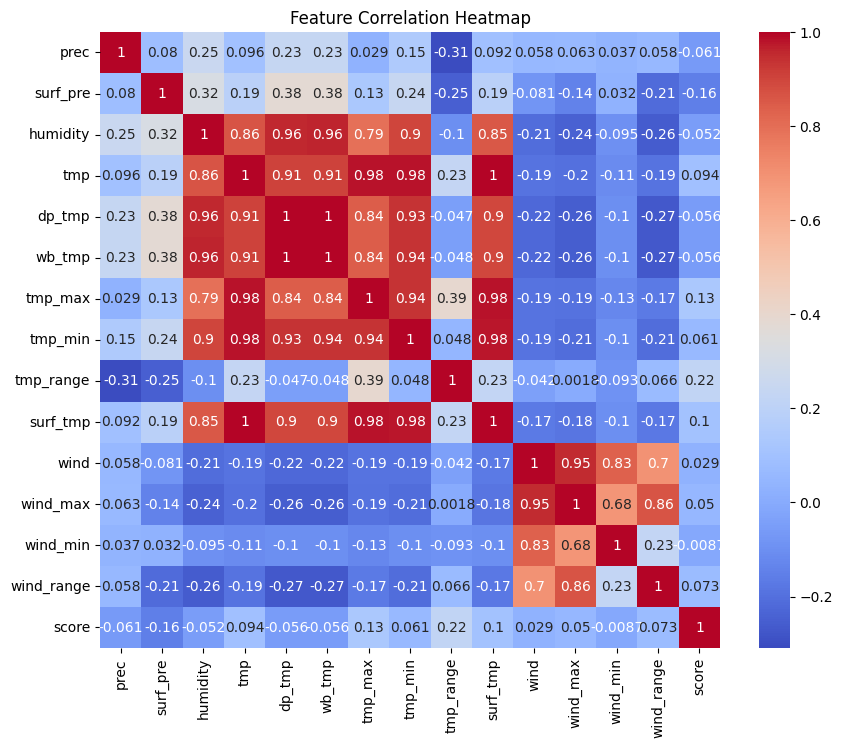

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

features_only = df.drop(columns=['region_id', 'date'])
corr_matrix = features_only.corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna(subset=targets + ['score']).copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")
# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================
print("--- FULL DATASET RETRAINING ---")

print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

features = [c for c in train_raw.columns if c not in ['region_id', 'date']]
# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_final = test_raw.copy()

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names].fillna(0).values
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].fillna(0).values

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")
final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region.csv', index=False)
print("\nSuccess! 'submission_weighted_master.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696
--- FULL DATASET RETRAINING ---
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...
Training Final Master Model on all 1746696 rows...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 114 dense feature groups (193.23 MB) transferred to GPU in 0.120189 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 114 dense feature groups (193.23 MB) transferred to GPU in 0.120616 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 28605
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 114
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
cols_to_baseline = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
climate_normals = train_raw.groupby(['region_id', 'month'])[cols_to_baseline].mean().reset_index()
climate_normals = climate_normals.rename(columns={c: f'normal_{c}' for c in cols_to_baseline})

train_raw = train_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna(subset=targets + ['score']).copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on=['region_id', 'month'], how='left')

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, region_avg_score)

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")
# ==========================================
# CELL 2: 100% RETRAIN & KAGGLE SUBMISSION
# ==========================================
print("--- FULL DATASET RETRAINING ---")

print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals, on=['region_id', 'month'], how='left')

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
weather_cols = ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']
windows = [7, 14, 28, 49, 84]

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())

        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in [7, 14, 28, 49, 84]:
    for col in ['prec', 'tmp', 'humidity', 'wind', 'surf_tmp', 'evap_stress']:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.copy()

test_final = add_future_month_features(test_final, region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names].copy()
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
test_submission_rows = test_final.groupby('region_id').last().reset_index()

X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_70_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696
--- FULL DATASET RETRAINING ---
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...
Training Final Master Model on all 1746696 rows...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 142 dense feature groups (239.87 MB) transferred to GPU in 0.148714 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 142 dense feature groups (239.87 MB) transferred to GPU in 0.147180 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 34535
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 142
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [2]:
final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.round(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.10, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.10, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_70_window_region_monthly_down_20_up_10.csv', index=False)
print("\nSuccess! 'submission_70_window_region_monthly.csv' is saved and ready to upload to Kaggle.")


Success! 'submission_70_window_region_monthly.csv' is saved and ready to upload to Kaggle.


In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 35]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 35:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna().copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_final.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=1000, num_leaves=95, learning_rate=0.015, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, device='gpu'
)).fit(X, y)

del train_final, X, y
gc.collect()

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 35:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna().copy()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_5_week_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_last_5_week_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1737704
Training Final Master Model on all 1737704 rows...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 40400
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 165
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 165 dense feature groups (278.41 MB) transferred to GPU in 0.175421 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 40400
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 165
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 165 dense feature groups (278.41 MB) transferred to GPU in 0.167442 secs. 0 sparse feature groups
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 40400
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 165
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Com

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 35]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna().copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_final.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=3000, num_leaves=95, learning_rate=0.01, 
    subsample=0.6, colsample_bytree=0.6, random_state=42, n_jobs=-1, lambda_l1 = '1', lambda_l2 = '1',device='gpu'
)).fit(X, y)

del train_final, X, y
gc.collect()

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna().copy()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_5_week_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_last_5_week_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1737704
Training Final Master Model on all 1737704 rows...
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 173 dense feature groups (291.67 MB) transferred to GPU in 0.200139 secs. 0 sparse feature groups
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram 

**Consider ACF and PACF**

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 35]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna().copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_final.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=4000, num_leaves=95, learning_rate=0.01, 
    subsample=0.6, colsample_bytree=0.6, random_state=42, n_jobs=-1, lambda_l1 = '2', lambda_l2 = '2',device='gpu'
)).fit(X, y)

del train_final, X, y
gc.collect()

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna().copy()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.25, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_5_week_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_last_5_week_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1737704
Training Final Master Model on all 1737704 rows...
[LightGBM] [Warning] lambda_l2 is set=2, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=2, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 173 dense feature groups (291.67 MB) transferred to GPU in 0.210020 secs. 0 sparse feature groups
[LightGBM] [Warning] lambda_l2 is set=2, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=2, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram 

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 35]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna().copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_final.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=5000, num_leaves=63, learning_rate=0.01, 
    subsample=0.6, subsample_freq = 1 ,colsample_bytree=0.6, random_state=42, n_jobs=-1, lambda_l1 = '2', lambda_l2 = '20',device='gpu'
)).fit(X, y)

del train_final, X, y
gc.collect()

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).max())
        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna().copy()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.25, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_5_week_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_last_5_week_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1737704
Training Final Master Model on all 1737704 rows...
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 173 dense feature groups (291.67 MB) transferred to GPU in 0.177760 secs. 0 sparse feature groups
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 42440
[LightGBM] [Info] Number of data points in the train set: 1737704, number of used features: 173
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histog

above is the latest, below is trial

In [2]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])
train_raw['evap_demand'] = train_raw['tmp_max'] / (train_raw['prec'] * 0.01)

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp', 'evap_demand']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 42]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).max())
        if w >= 28:
            train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']
        
train_final = train_raw.dropna().copy()

# Convert the region_id from a text string to a Pandas 'category' type
train_final['region_id'] = train_final['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_final.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_final = train_final.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_final.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_final.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=5000, num_leaves=63, learning_rate=0.01, 
    subsample=0.6, subsample_freq = 1 ,colsample_bytree=0.6, random_state=42, n_jobs=-1, lambda_l1 = '2', lambda_l2 = '20',device='gpu'
)).fit(X, y)

del train_final, X, y
gc.collect()

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])
test_raw['evap_demand'] = test_raw['tmp_max'] / (test_raw['prec'] * 0.01)

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).max())
        if w >= 28:
            test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna().copy()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names].copy()

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_4&8_weeks_window_region_monthly.csv', index=False)
print("\nSuccess! 'submission_last_4&8_weeks_window_region_monthly.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1205688
Training Final Master Model on all 1205688 rows...
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 46940
[LightGBM] [Info] Number of data points in the train set: 1205688, number of used features: 192
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 186 dense feature groups (216.17 MB) transferred to GPU in 0.138295 secs. 1 sparse feature groups
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 46940
[LightGBM] [Info] Number of data points in the train set: 1205688, number of used features: 192
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histog

In [1]:
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import gc
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("1. Loading raw datasets...")
train_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/train.csv')

# Parse dates
train_date_parts = train_raw['date'].str.split('-', expand=True)
train_raw['year'] = train_date_parts[0].astype(int)
train_raw['month'] = train_date_parts[1].astype(int)
train_raw['day'] = train_date_parts[2].astype(int)

train_raw = train_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# Targets
targets = ['target_w1', 'target_w2', 'target_w3', 'target_w4', 'target_w5']
for i, t in enumerate(targets):
    train_raw[t] = train_raw.groupby('region_id')['score'].shift(-(i+1)*7)

# THE GOLD STANDARD FEATURES
train_raw['evap_stress'] = train_raw['tmp_max'] * (100 - train_raw['humidity'])
train_raw['evap_demand'] = train_raw['tmp_max'] / ((train_raw['prec'] + 0.001)* 0.01)

# Climate Normals Baselines
weather_cols = ['prec', 'humidity', 'wind', 'surf_tmp', 'evap_stress', 'surf_pre', 'dp_tmp', 'tmp', 'evap_demand', 'wb_tmp']
climate_normals_region_month = train_raw.groupby(['region_id', 'month'])[weather_cols].mean().reset_index()
climate_normals_region_month = climate_normals_region_month.rename(columns={c: f'normal_{c}' for c in weather_cols})

train_raw = train_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")
windows = [7, 14, 21, 28, 42, 84]

for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_roll_mean_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).mean())
        train_raw[f'{col}_roll_max_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).max())
        train_raw[f'{col}_roll_std_{w}'] = train_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w,min_periods=1).std())

train_raw = train_raw.dropna()

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        train_raw[f'{col}_anomaly_{w}'] = train_raw[f'{col}_roll_mean_{w}'] - train_raw[f'normal_{col}']

for col in weather_cols:
    train_raw[f'{col}_vel_7_28'] = train_raw[f'{col}_roll_mean_7'] - train_raw[f'{col}_roll_mean_28']
    train_raw[f'{col}_vel_28_84'] = train_raw[f'{col}_roll_mean_28'] - train_raw[f'{col}_roll_mean_84']
    
# Convert the region_id from a text string to a Pandas 'category' type
train_raw['region_id'] = train_raw['region_id'].astype('category')

# Calculate the historical average score for each region
region_avg_score = train_raw.groupby('region_id')['score'].mean().reset_index().rename(columns={'score': 'historical_region_score'})

# Merge this back into your main dataframe
train_raw = train_raw.merge(region_avg_score, on='region_id', how='left')

# Monthly region average score
month_region_avg_score = train_raw.groupby(['region_id', 'month'])['score'].mean().reset_index().rename(columns={'score': 'month_region_score'})
# Merge this back into your main dataframe
train_final = train_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

MONTH_LEN = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def is_leap_year(y):
    return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)

def add_days_get_future_month(year, month, day, add_days):
    y, m, d = int(year), int(month), int(day)
    
    while add_days > 0:
        month_len = 29 if (m == 2 and is_leap_year(y)) else MONTH_LEN[m]
        days_left_in_month = month_len - d
        
        if add_days <= days_left_in_month:
            d += add_days
            add_days = 0
        else:
            add_days -= (days_left_in_month + 1)
            d = 1
            m += 1
            if m > 12:
                m = 1
                y += 1
    
    return m
    
def add_future_month_features(df, region_avg_score, horizons=(1, 2, 3, 4, 5)):
    df = df.copy()
    
    for h in horizons:
        add_days = 7 * h
        df[f'future_month_w{h}'] = [
            add_days_get_future_month(y, m, d, add_days)
            for y, m, d in zip(df['year'], df['month'], df['day'])
        ]
        
        tmp = df[['region_id', f'future_month_w{h}']].rename(
            columns={f'future_month_w{h}': 'month'}
        )
        
        tmp = tmp.merge(
            region_avg_score,
            on=['region_id', 'month'],
            how='left'
        )

        df[f'future_region_month_score_w{h}'] = tmp['month_region_score'].values

    return df

train_final = add_future_month_features(train_final, month_region_avg_score)

feature_names = [c for c in train_final.columns if c not in ['region_id', 'date', 'score', 'year'] + targets]

X = train_final[feature_names]
y = train_final[targets].values

# 1. We use the FULL dataset (X, y, and global_sample_weights from Cell 1)
print(f"Training Final Master Model on all {len(X)} rows...")

master_model = MultiOutputRegressor(LGBMRegressor(
    objective='mae', n_estimators=5000, num_leaves=63, learning_rate=0.01, 
    subsample=0.8, subsample_freq = 1 ,colsample_bytree=0.6, random_state=42, n_jobs=-1, lambda_l1 = '2', lambda_l2 = '20',device='gpu'
)).fit(X, y)

# 2. Prepare the Test Set (Assuming test_final is your pre-processed test.csv)
# We group by region_id and take the last chronological row for the final prediction
print("1. Loading raw datasets...")
test_raw = pd.read_csv('/kaggle/input/datasets/dhammaruciwl/data-mining-final-project/data/test.csv')

# Parse dates
test_date_parts = test_raw['date'].str.split('-', expand=True)
test_raw['year'] = test_date_parts[0].astype(int)
test_raw['month'] = test_date_parts[1].astype(int)
test_raw['day'] = test_date_parts[2].astype(int)

test_raw = test_raw.sort_values(['region_id', 'date']).reset_index(drop=True)

# THE GOLD STANDARD FEATURES
test_raw['evap_stress'] = test_raw['tmp_max'] * (100 - test_raw['humidity'])
test_raw['evap_demand'] = test_raw['tmp_max'] / ((test_raw['prec'] + 0.001)* 0.01)

# Climate Normals Baselines
test_raw = test_raw.merge(climate_normals_region_month, on=['region_id', 'month'], how='left')

# --- SAFE WINDOWS (No Velocity!) ---
print("Engineering capped rolling windows...")

for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_roll_mean_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).mean())
        test_raw[f'{col}_roll_max_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).max())
        test_raw[f'{col}_roll_std_{w}'] = test_raw.groupby('region_id')[col].transform(lambda x: x.rolling(w, min_periods=1).std())

# Anomalies
print("Engineering regional anomalies...")
for w in windows:
    for col in weather_cols:
        test_raw[f'{col}_anomaly_{w}'] = test_raw[f'{col}_roll_mean_{w}'] - test_raw[f'normal_{col}']

for col in weather_cols:
    test_raw[f'{col}_vel_7_28'] = test_raw[f'{col}_roll_mean_7'] - test_raw[f'{col}_roll_mean_28']
    test_raw[f'{col}_vel_28_84'] = test_raw[f'{col}_roll_mean_28'] - test_raw[f'{col}_roll_mean_84']
    
# Convert the region_id from a text string to a Pandas 'category' type
test_raw['region_id'] = test_raw['region_id'].astype('category')

# Merge this back into your main dataframe
test_raw = test_raw.merge(region_avg_score, on='region_id', how='left')
test_raw = test_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')
test_final = test_raw.dropna()

test_final = add_future_month_features(test_final, month_region_avg_score)
test_submission_rows = test_final.groupby('region_id').last().reset_index()
X_test = test_submission_rows[feature_names]

# 3. Predict the future 5 weeks!
print("Generating Final 5-Week Forecasts...")

final_predictions = np.clip(master_model.predict(X_test), 0, 5)

# 3.a Find the nearest whole number for every single prediction
rounded_preds = np.floor(final_predictions)

# 3.b Calculate the absolute distance between the continuous prediction and the whole number
distance_to_int = np.abs(final_predictions - rounded_preds)

# 3.c If the distance is less than 0.20, snap to the whole number. Otherwise, keep the decimal.
final_predictions = np.where(distance_to_int < 0.20, rounded_preds, final_predictions)

# 4. Format the output exactly as Kaggle demands
submission = pd.DataFrame({
    'region_id': test_submission_rows['region_id'],
    'pred_week1': final_predictions[:, 0],
    'pred_week2': final_predictions[:, 1],
    'pred_week3': final_predictions[:, 2],
    'pred_week4': final_predictions[:, 3],
    'pred_week5': final_predictions[:, 4]
})

# Save the file
submission.to_csv('submission_last_4&6&12_weeks_window_region_monthly_all.csv', index=False)
print("\nSuccess! 'submission_last_4&6&12_weeks_window_region_monthly_all.csv' is saved and ready to upload to Kaggle.")

Using device: cuda
1. Loading raw datasets...
Engineering capped rolling windows...
Engineering regional anomalies...

Total 7th-day valid labeled rows available for Model 1: 1746696
Training Final Master Model on all 1746696 rows...
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 74825
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 300
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 300 dense feature groups (499.73 MB) transferred to GPU in 0.295317 secs. 0 sparse feature groups
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Warning] lambda_l2 is set=20, reg_lambda=0.0 will be ignored. Current value: lambda_l2=20
[LightGBM] [Warning] lambda_l1 is set=2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 74825
[LightGBM] [Info] Number of data points in the train set: 1746696, number of used features: 300
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histog

In [4]:
# Merge this back into your main dataframe
train_final = train_raw.merge(month_region_avg_score, on=['region_id', 'month'], how='left')

print(f"\nTotal 7th-day valid labeled rows available for Model 1: {len(train_final)}")

train_final = add_future_month_features(train_final, month_region_avg_score)
X = train_final[feature_names]
y = train_final[targets].values

for i in range(5):
    print(f"\n--- Top 20 Features for Week {i+1} ---")
    df_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': master_model.estimators_[i].feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    # to_string(index=False) hides the arbitrary row numbers for a cleaner console print
    print(df_imp.to_string(index=False))


Total 7th-day valid labeled rows available for Model 1: 1746696

--- Top 20 Features for Week 1 ---
                feature  importance
                    day        6409
    surf_pre_anomaly_42        6057
 evap_stress_anomaly_42        4948
   surf_pre_roll_std_42        4931
    surf_pre_anomaly_28        4679
      prec_roll_mean_42        4655
        prec_anomaly_42        4467
    surf_pre_anomaly_21        4457
      dp_tmp_anomaly_42        4440
    surf_tmp_anomaly_42        4362
    surf_pre_anomaly_14        4201
    humidity_anomaly_42        3942
        wind_anomaly_42        3659
     surf_pre_anomaly_7        3654
      wb_tmp_anomaly_42        3282
 evap_stress_anomaly_28        3089
   surf_pre_roll_std_28        2966
                  month        2864
 evap_stress_anomaly_21        2747
historical_region_score        2630

--- Top 20 Features for Week 2 ---
                     feature  importance
                         day        6825
         surf_pre_anomaly